# 3D Tetrahedral Sign Check — extending the 2-triangle check to 3D

Companion to [01_vs-central-diff.ipynb](01_vs-central-diff.ipynb). The 2D 2-triangle check splits each quad cell along the TR-BL diagonal into 2 triangles and flags `min(T1, T2) <= 0` as a fold. Central-difference Jacobian determinant misses these folds when its 2Δ stencil averaging cancels their gradient contributions — the canonical bowtie.

This notebook lifts the same idea to 3D. We split each voxel cell along the body diagonal `v0=(0,0,0) → v7=(1,1,1)` into **6 tetrahedra** — the structural analog of "one shared diagonal, minimum-by-shared-diagonal simplex count." Each tet has signed volume `V = (1/6) · (b−a) · ((c−a) × (d−a))`. Per-cell `min(V0, ..., V5) <= 0` flags a fold.

We then run SLSQP under the tet-volume constraint and compare against SLSQP under the existing central-diff Jdet constraint on synthetic 3D bowtie test cases.

In [1]:
import os, sys, time
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)
from scipy.optimize import minimize, NonlinearConstraint

from dvfopt import DEFAULT_PARAMS
from dvfopt.jacobian.numpy_jdet import _numpy_jdet_3d, jacobian_det3D
from dvfopt.core.objective import objective_euc

THRESHOLD = DEFAULT_PARAMS['threshold']
print(f'THRESHOLD = {THRESHOLD}')

THRESHOLD = 0.01


## Geometry — 6-tet decomposition

A voxel cell has 8 corners indexed by `(z, y, x)` offset:

```
v0 = (0,0,0)   v4 = (1,0,0)
v1 = (0,0,1)   v5 = (1,0,1)
v2 = (0,1,0)   v6 = (1,1,0)
v3 = (0,1,1)   v7 = (1,1,1)
```

The body diagonal `v0 → v7` has Hamming distance 3 in `(z,y,x)` bits, so there are `3! = 6` monotone edge paths from `v0` to `v7`. Each path defines a tetrahedron `(v0, A, B, v7)` where `A` and `B` are the two intermediate corners on the path. All 6 tets share the body diagonal as an edge.

| tet | path | A | B |
|----|----|----|----|
| T0 | x, y, z | v1 | v3 |
| T1 | x, z, y | v1 | v5 |
| T2 | y, x, z | v2 | v3 |
| T3 | y, z, x | v2 | v6 |
| T4 | z, x, y | v4 | v5 |
| T5 | z, y, x | v4 | v6 |

Half of these orderings are even permutations and half odd, so the raw scalar triple product `(b−a)·((c−a)×(d−a))` returns `+1` for some tets and `−1` for others on the unwarped reference cube. We compute the 6 unwarped signs once at notebook startup and apply a fixed per-tet `±1` flip vector so that valid (positive-Jacobian) cells always return strictly positive volumes for all 6 tets.

## Helpers

In [2]:
# 8 cube corners as (z, y, x) offsets, indexed v0..v7 with z*4 + y*2 + x.
CUBE_CORNERS = np.array([
    [0, 0, 0],  # v0
    [0, 0, 1],  # v1
    [0, 1, 0],  # v2
    [0, 1, 1],  # v3
    [1, 0, 0],  # v4
    [1, 0, 1],  # v5
    [1, 1, 0],  # v6
    [1, 1, 1],  # v7
], dtype=np.int8)

# 6-tet body-diagonal decomposition: each row is (v0, A, B, v7) for one of the
# 3! monotone paths from v0 to v7. See the markdown table above.
TET_INDICES = np.array([
    [0, 1, 3, 7],  # T0  path x, y, z
    [0, 1, 5, 7],  # T1  path x, z, y
    [0, 2, 3, 7],  # T2  path y, x, z
    [0, 2, 6, 7],  # T3  path y, z, x
    [0, 4, 5, 7],  # T4  path z, x, y
    [0, 4, 6, 7],  # T5  path z, y, x
], dtype=np.int8)


def warp_corners(phi):
    """Return warped (x, y, z) coordinates of every voxel.

    phi : ndarray, shape (3, D, H, W) with channels [dz, dy, dx].
    Returns ndarray, shape (D, H, W, 3) with last axis = (x, y, z).
    """
    D, H, W = phi.shape[1:]
    zz, yy, xx = np.mgrid[:D, :H, :W]
    dz, dy, dx = phi[0], phi[1], phi[2]
    return np.stack([xx + dx, yy + dy, zz + dz], axis=-1)

In [3]:
# Sanity: identity field warps to identity, shape is right.
phi0 = np.zeros((3, 4, 5, 6))
Wc = warp_corners(phi0)
assert Wc.shape == (4, 5, 6, 3)
assert np.allclose(Wc[2, 3, 4], [4, 3, 2])  # corner (z=2,y=3,x=4) -> (x=4,y=3,z=2)
print('warp_corners OK')

warp_corners OK


### Step 1 — start with one voxel cube

Before any decomposition, this is the object we're working with: one voxel cell of the deformation grid, with its 8 corners labeled `v_i` and tagged with their `(z, y, x)` offsets — exactly what's spelled out in the geometry markdown above. The walkthrough that follows splits this cube into 6 tetrahedra, computes a signed volume per tet, and shows how SLSQP uses those volumes as constraints.

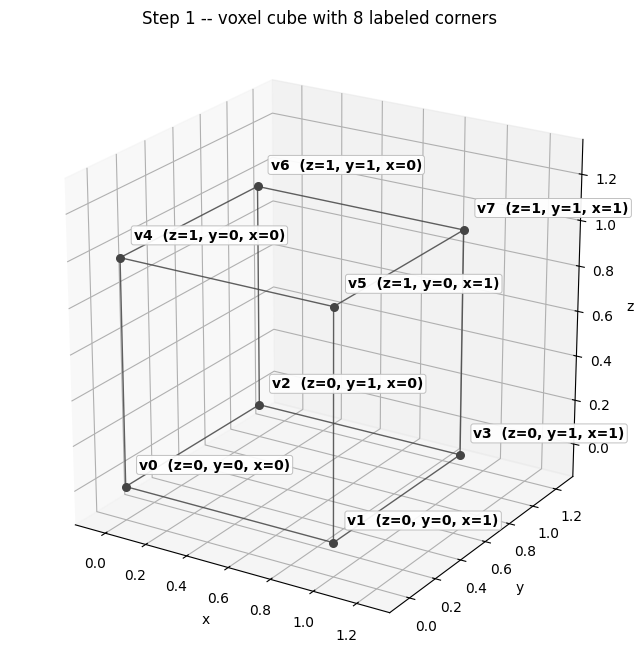

In [4]:
# Step 1 is self-contained: just draw the unit cube with labeled corners.
# (The helpers used by later steps come from the cube-decomposition cell below.)
from mpl_toolkits.mplot3d.art3d import Poly3DCollection  # used by later steps too

CUBE_EDGES = [
    (0,1),(0,2),(0,4),(1,3),(1,5),(2,3),(2,6),(3,7),(4,5),(4,6),(5,7),(6,7),
]


def _xyz(c):
    return float(c[2]), float(c[1]), float(c[0])


fig = plt.figure(figsize=(7.5, 6.5), layout='constrained')
ax = fig.add_subplot(111, projection='3d')
for i, j in CUBE_EDGES:
    x0, y0, z0 = _xyz(CUBE_CORNERS[i])
    x1, y1, z1 = _xyz(CUBE_CORNERS[j])
    ax.plot([x0, x1], [y0, y1], [z0, z1], color='#444444', lw=1.0, alpha=0.85)
for i, c in enumerate(CUBE_CORNERS):
    x, y, z = _xyz(c)
    cz, cy, cx = int(c[0]), int(c[1]), int(c[2])
    label = "v" + str(i) + "  (z=" + str(cz) + ", y=" + str(cy) + ", x=" + str(cx) + ")"
    ax.text(x + 0.04, y + 0.04, z + 0.06, label,
            color='black', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.18', facecolor='white',
                      edgecolor='#bbbbbb', linewidth=0.7, alpha=0.92),
            ha='left', va='bottom')
    ax.scatter(x, y, z, color='#444444', s=30, zorder=10)
ax.set_xlim(-0.15, 1.35); ax.set_ylim(-0.15, 1.35); ax.set_zlim(-0.15, 1.35)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=22, azim=-58)
ax.set_title('Step 1 -- voxel cube with 8 labeled corners', fontsize=12)
plt.show()

### Visualizing the cube → 6-tet decomposition

The figure below makes the structure concrete:

- **Panel 1.** A single voxel cube with all 8 corners `v0..v7` labeled by their `(z, y, x)` offsets. The **red** edge is the body diagonal `v0 → v7` — every tet shares it.
- **Panels 2–7.** Each tet `T0..T5` drawn individually inside the cube outline. The 4 vertices are marked with dots; the **3 thick coloured edges** trace the monotone `(v0, A, B, v7)` path through cube edges; the **filled translucent volume** is the tet itself; the red diagonal is shown for context.
- **Panel 8.** All 6 tets stacked at low opacity. They share the body diagonal, have disjoint interiors, and their union is the whole cube — that is what makes this a valid decomposition.

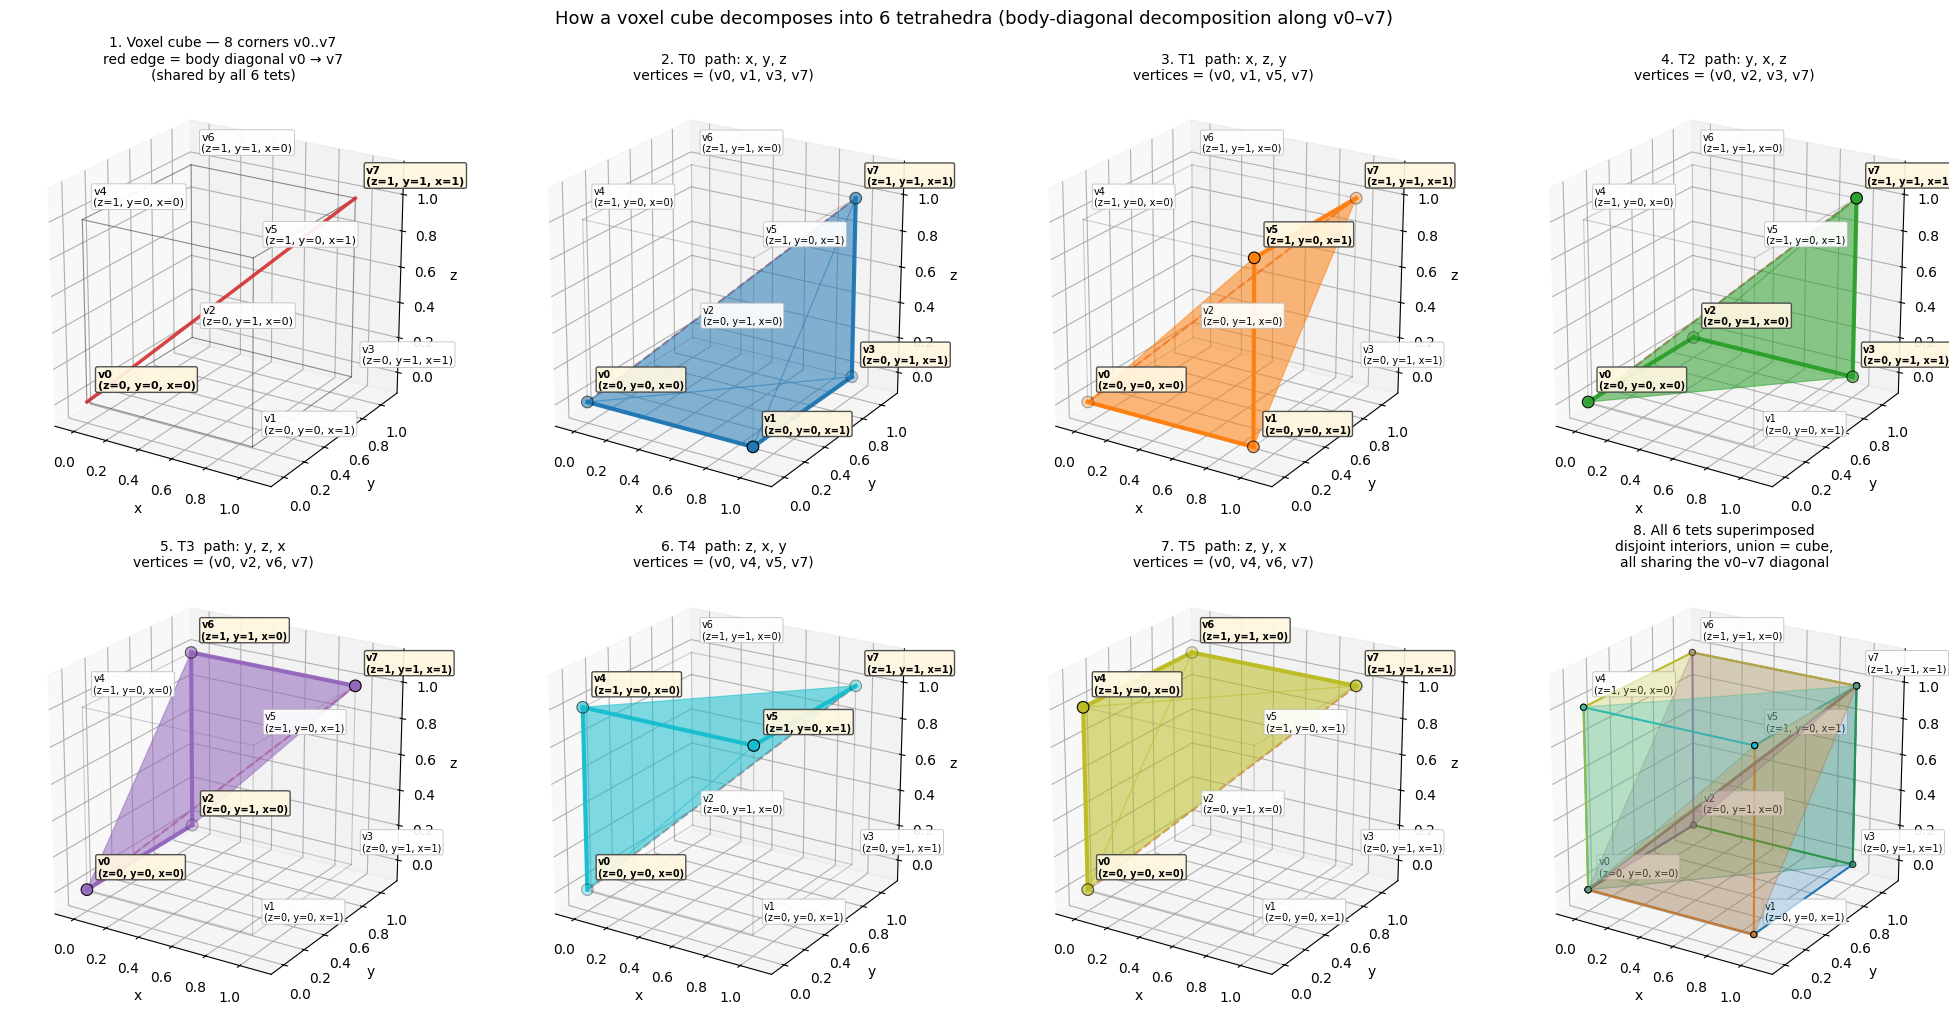

 tet  vertices                      path         V_signed     |V|
  T0  (v0,v1,v3,v7)                 x, y, z       +0.1667  0.1667
  T1  (v0,v1,v5,v7)                 x, z, y       -0.1667  0.1667
  T2  (v0,v2,v3,v7)                 y, x, z       -0.1667  0.1667
  T3  (v0,v2,v6,v7)                 y, z, x       +0.1667  0.1667
  T4  (v0,v4,v5,v7)                 z, x, y       +0.1667  0.1667
  T5  (v0,v4,v6,v7)                 z, y, x       -0.1667  0.1667

sum of |V_t| = 1.0000   (expected 1.0 = cube volume)
-> the 6 tets tile the unit cube with no overlap and no gap.


In [5]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 12 edges of the unit cube (pairs of v_i indices).
CUBE_EDGES = [
    (0,1),(0,2),(0,4),(1,3),(1,5),(2,3),(2,6),(3,7),(4,5),(4,6),(5,7),(6,7),
]

# Distinct, colour-blind-friendly hues for T0..T5.
TET_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#17becf', '#bcbd22']

# Path labels (which axis bit is flipped at each step v0 -> A -> B -> v7).
TET_PATHS = ['x, y, z', 'x, z, y', 'y, x, z', 'y, z, x', 'z, x, y', 'z, y, x']


def _xyz(corner_zyx):
    """Convert a (z, y, x) corner offset to (x, y, z) for matplotlib's 3D axes."""
    return float(corner_zyx[2]), float(corner_zyx[1]), float(corner_zyx[0])


def _draw_cube(ax, edge_alpha=0.6, label_corners=True, label_size=9,
               label_with_coords=True, highlight_vs=None):
    for i, j in CUBE_EDGES:
        x0, y0, z0 = _xyz(CUBE_CORNERS[i])
        x1, y1, z1 = _xyz(CUBE_CORNERS[j])
        ax.plot([x0, x1], [y0, y1], [z0, z1], color='#444444', lw=0.8, alpha=edge_alpha)
    if label_corners:
        for i, c in enumerate(CUBE_CORNERS):
            x, y, z = _xyz(c)
            cz, cy, cx = int(c[0]), int(c[1]), int(c[2])
            text = f'v{i}\n(z={cz}, y={cy}, x={cx})' if label_with_coords else f'v{i}'
            is_highlight = highlight_vs is not None and i in highlight_vs
            bbox = dict(boxstyle='round,pad=0.18',
                        facecolor='#fff7e0' if is_highlight else 'white',
                        edgecolor='#444444' if is_highlight else '#bbbbbb',
                        linewidth=1.0 if is_highlight else 0.6,
                        alpha=0.92)
            ax.text(x + 0.04, y + 0.04, z + 0.06, text,
                    color='black', fontsize=label_size,
                    fontweight='bold' if is_highlight else 'normal',
                    bbox=bbox, ha='left', va='bottom')


def _draw_diagonal(ax, color='#d32f2f', lw=2.5, alpha=0.9, dashed=False):
    x0, y0, z0 = _xyz(CUBE_CORNERS[0])
    x1, y1, z1 = _xyz(CUBE_CORNERS[7])
    ax.plot([x0, x1], [y0, y1], [z0, z1],
            color=color, lw=lw, alpha=alpha,
            linestyle='--' if dashed else '-')


def _draw_tet(ax, t, color, fill_alpha=0.32, path_lw=3.0, marker_size=70):
    """Draw tet T_t: filled volume + path edges + vertex markers."""
    inds = TET_INDICES[t]
    pts = np.array([_xyz(CUBE_CORNERS[i]) for i in inds])  # (4, 3)

    # Fill the 4 faces.
    faces = [
        [pts[0], pts[1], pts[2]],
        [pts[0], pts[1], pts[3]],
        [pts[0], pts[2], pts[3]],
        [pts[1], pts[2], pts[3]],
    ]
    poly = Poly3DCollection(faces, facecolor=color, alpha=fill_alpha,
                             edgecolor=color, linewidth=0.8)
    ax.add_collection3d(poly)

    # Highlight the (v0, A, B, v7) monotone path with thick coloured segments.
    for k in range(3):
        p, q = pts[k], pts[k + 1]
        ax.plot([p[0], q[0]], [p[1], q[1]], [p[2], q[2]],
                color=color, lw=path_lw, alpha=0.95)

    # Vertex dots.
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], color=color,
               s=marker_size, edgecolor='black', linewidth=0.8, zorder=10)


def _set_cube_view(ax, elev=22, azim=-58):
    ax.set_xlim(-0.12, 1.18); ax.set_ylim(-0.12, 1.18); ax.set_zlim(-0.12, 1.18)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=elev, azim=azim)


fig = plt.figure(figsize=(20, 10), layout='constrained')

# Panel 1: labeled cube + body diagonal — emphasise the diagonal endpoints.
ax0 = fig.add_subplot(2, 4, 1, projection='3d')
_draw_cube(ax0, label_size=8, highlight_vs={0, 7})
_draw_diagonal(ax0)
_set_cube_view(ax0)
ax0.set_title('1. Voxel cube — 8 corners v0..v7\n'
              'red edge = body diagonal v0 → v7\n'
              '(shared by all 6 tets)', fontsize=10)

# Panels 2–7: each tet individually. Highlight that tet's 4 vertex labels.
for t in range(6):
    ax = fig.add_subplot(2, 4, t + 2, projection='3d')
    inds = TET_INDICES[t]
    _draw_cube(ax, edge_alpha=0.25, label_size=7, highlight_vs=set(inds))
    _draw_diagonal(ax, lw=1.6, alpha=0.55, dashed=True)
    _draw_tet(ax, t, TET_COLORS[t])
    _set_cube_view(ax)
    ax.set_title(f'{t + 2}. T{t}  path: {TET_PATHS[t]}\n'
                 f'vertices = (v{inds[0]}, v{inds[1]}, v{inds[2]}, v{inds[3]})',
                 fontsize=10)

# Panel 8: all 6 tets stacked.
ax_all = fig.add_subplot(2, 4, 8, projection='3d')
_draw_cube(ax_all, edge_alpha=0.55, label_size=7)
for t in range(6):
    _draw_tet(ax_all, t, TET_COLORS[t], fill_alpha=0.13, path_lw=1.5, marker_size=20)
_draw_diagonal(ax_all, lw=2.0)
_set_cube_view(ax_all)
ax_all.set_title('8. All 6 tets superimposed\n'
                 'disjoint interiors, union = cube,\n'
                 'all sharing the v0–v7 diagonal', fontsize=10)

plt.suptitle('How a voxel cube decomposes into 6 tetrahedra '
             '(body-diagonal decomposition along v0–v7)', fontsize=13)
plt.show()


# Sanity: the 6 tets' unsigned volumes (raw scalar triple products /6) sum to 1.
# This proves they tile the cube without overlap or gap. Their *signed* volumes
# alternate +1/6 and -1/6 by the parity of the path orderings (which is exactly
# what TET_SIGN_FLIP corrects for downstream).
def _tet_volume_signed(pts_xyz):
    a, b, c, d = pts_xyz
    return float(np.dot(b - a, np.cross(c - a, d - a))) / 6.0


total_unsigned = 0.0
print(f'{"tet":>4s}  {"vertices":<28s}  {"path":<10s}  {"V_signed":>9s}  {"|V|":>6s}')
for t in range(6):
    inds = TET_INDICES[t]
    pts = np.array([_xyz(CUBE_CORNERS[i]) for i in inds])
    v_signed = _tet_volume_signed(pts)
    total_unsigned += abs(v_signed)
    print(f'  T{t}  {"(v" + ",v".join(str(i) for i in inds) + ")":<28s}  '
          f'{TET_PATHS[t]:<10s}  {v_signed:+9.4f}  {abs(v_signed):>6.4f}')
print(f'\nsum of |V_t| = {total_unsigned:.4f}   (expected 1.0 = cube volume)')
print('-> the 6 tets tile the unit cube with no overlap and no gap.')

In [6]:
def _tet_volumes_unsigned(corners):
    """Compute the 6 raw tet scalar triple products per cell.

    Output shape: (6, D-1, H-1, W-1). Not yet divided by 6 and not yet
    sign-flipped (some entries are negative on the reference cube).
    """
    cell_corners = []
    for (oz, oy, ox) in CUBE_CORNERS:
        cell_corners.append(corners[oz:corners.shape[0] - 1 + oz,
                                     oy:corners.shape[1] - 1 + oy,
                                     ox:corners.shape[2] - 1 + ox])
    cell_corners = np.stack(cell_corners, axis=0)  # (8, D-1, H-1, W-1, 3)

    raw = np.empty((6,) + cell_corners.shape[1:-1], dtype=corners.dtype)
    for ti, (ia, ib, ic, id_) in enumerate(TET_INDICES):
        a = cell_corners[ia]; b = cell_corners[ib]
        c = cell_corners[ic]; d = cell_corners[id_]
        ab = b - a; ac = c - a; ad = d - a
        cx = ac[..., 1] * ad[..., 2] - ac[..., 2] * ad[..., 1]
        cy = ac[..., 2] * ad[..., 0] - ac[..., 0] * ad[..., 2]
        cz = ac[..., 0] * ad[..., 1] - ac[..., 1] * ad[..., 0]
        raw[ti] = ab[..., 0] * cx + ab[..., 1] * cy + ab[..., 2] * cz
    return raw


def _calibrate_sign_flip():
    """One-time per-tet ±1 flip so that the unwarped reference cube returns
    strictly positive volumes for all 6 tets."""
    phi_id = np.zeros((3, 2, 2, 2))
    raw_id = _tet_volumes_unsigned(warp_corners(phi_id))  # (6, 1, 1, 1)
    flip = np.sign(raw_id[:, 0, 0, 0]).astype(np.float64)
    if np.any(flip == 0):
        raise RuntimeError(f'Degenerate identity-field tet volumes: {raw_id.ravel()}')
    return flip


TET_SIGN_FLIP = _calibrate_sign_flip()
print(f'TET_SIGN_FLIP = {TET_SIGN_FLIP}')


def tet_signed_volumes(phi):
    """Per-cell signed volumes of the 6-tet decomposition.

    phi : ndarray, shape (3, D, H, W) with channels [dz, dy, dx].
    Returns ndarray, shape (6, D-1, H-1, W-1). Positive = valid,
    zero = degenerate, negative = flip.
    """
    raw = _tet_volumes_unsigned(warp_corners(phi))
    return TET_SIGN_FLIP[:, None, None, None] * raw / 6.0


def tet_min_per_cell(phi):
    """Worst-of-6 signed volume per cell. Shape (D-1, H-1, W-1)."""
    return tet_signed_volumes(phi).min(axis=0)


def tet_count_negatives(phi):
    """Count of (tet, cell) pairs with signed volume <= 0."""
    return int((tet_signed_volumes(phi) <= 0).sum())

TET_SIGN_FLIP = [ 1. -1. -1.  1.  1. -1.]


In [7]:
# Sanity: identity field gives positive equal volumes for all 6 tets.
phi0 = np.zeros((3, 5, 5, 5))
V = tet_signed_volumes(phi0)
assert V.shape == (6, 4, 4, 4)
assert np.allclose(V, 1.0 / 6.0), f'Expected all 1/6, got min/max = {V.min()}, {V.max()}'

# Sanity: a uniform translation leaves all volumes unchanged.
phi_t = np.zeros((3, 5, 5, 5))
phi_t[0] += 0.3; phi_t[1] -= 0.7; phi_t[2] += 1.4
V_t = tet_signed_volumes(phi_t)
assert np.allclose(V_t, 1.0 / 6.0)

# Sanity: a uniform 2x scaling gives 2^3 / 6 per tet.
phi_s = np.zeros((3, 5, 5, 5))
zz, yy, xx = np.mgrid[:5, :5, :5]
phi_s[0] = zz; phi_s[1] = yy; phi_s[2] = xx  # corners (z,y,x) -> (2z,2y,2x)
V_s = tet_signed_volumes(phi_s)
assert np.allclose(V_s, 8.0 / 6.0), f'Expected 8/6, got min={V_s.min()}, max={V_s.max()}'

# Sanity: a single-voxel inversion folds a cell.
phi_fold = np.zeros((3, 3, 3, 3))
phi_fold[2, 1, 1, 1] = -2.5  # large -dx pulls centre voxel past its left neighbour
V_f = tet_signed_volumes(phi_fold)
assert (V_f <= 0).any(), 'Expected at least one negative tet for the inversion test'

print(f'Identity volume       : {V[0,0,0,0]:.6f}  (expected 1/6 = {1/6:.6f})')
print(f'Uniform 2x scaling    : {V_s[0,0,0,0]:.6f}  (expected 8/6 = {8/6:.6f})')
print(f'Inversion test n_neg  : {int((V_f <= 0).sum())}')
print('tet_signed_volumes OK')

Identity volume       : 0.166667  (expected 1/6 = 0.166667)
Uniform 2x scaling    : 1.333333  (expected 8/6 = 1.333333)
Inversion test n_neg  : 6
tet_signed_volumes OK


### Step 2 — compute the signed volume of one tetrahedron

Every tet has 4 vertices we label `(a, b, c, d)`, where `a = v0`, `b = v_A`, `c = v_B`, `d = v7` for the canonical `(v0, A, B, v7)` path ordering. The signed volume is

$$
V \;=\; \frac{1}{6}\;\bigl(\mathbf{b}-\mathbf{a}\bigr) \,\cdot\, \bigl[(\mathbf{c}-\mathbf{a})\times(\mathbf{d}-\mathbf{a})\bigr].
$$

The plot below shows tet **T0** with its three edge vectors `b−a`, `c−a`, `d−a` drawn from `a` in distinct colours. The right panel does the same for **T1** to illustrate that some tets' raw scalar triple product comes out **negative** before the per-tet sign flip — a consequence of the path ordering being an odd permutation of the cube's vertices.

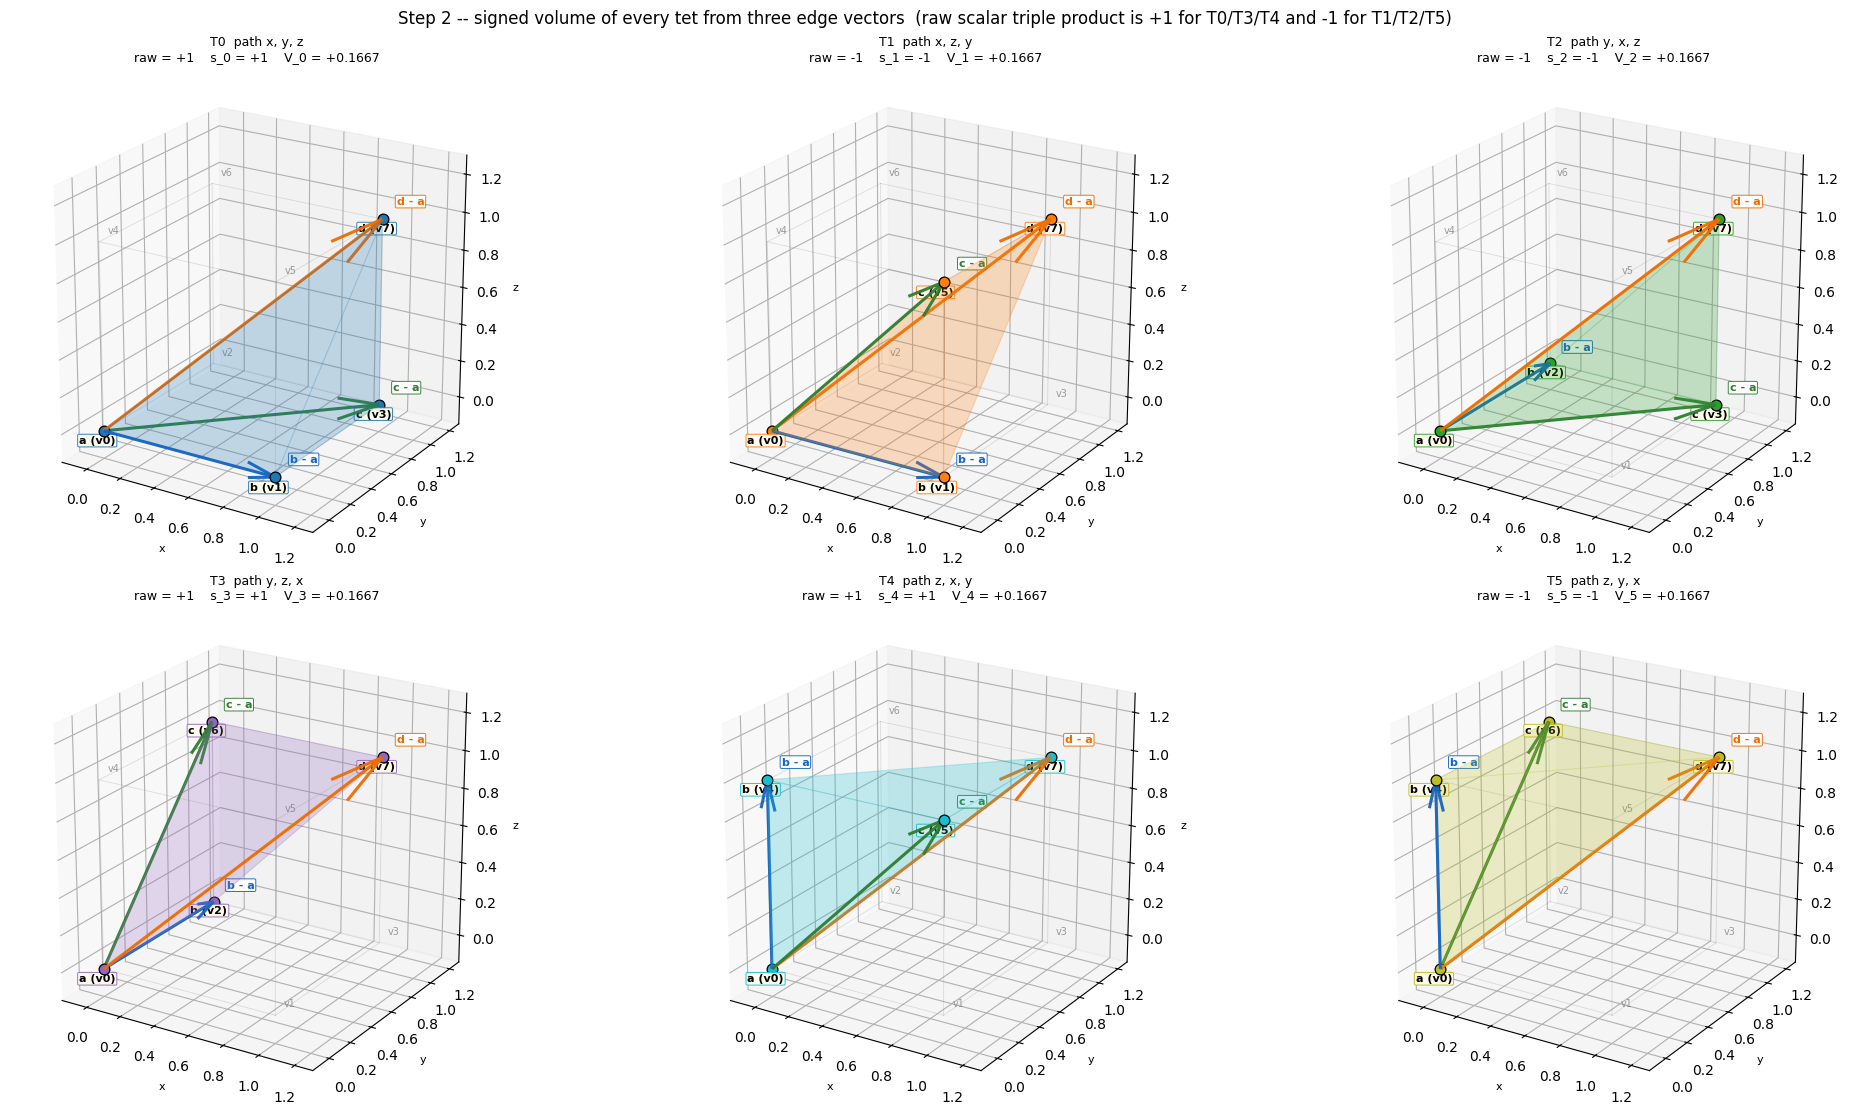

In [8]:
def _tet_compute(t):
    inds = TET_INDICES[t]
    pts = np.array([_xyz(CUBE_CORNERS[i]) for i in inds])  # (4, 3) in (x, y, z)
    a, b, c, d = pts
    ab = b - a; ac = c - a; ad = d - a
    n = np.cross(ac, ad)
    raw = float(np.dot(ab, n))
    s = float(TET_SIGN_FLIP[t])
    V = s * raw / 6.0
    return raw, s, V, pts


VEC_COLORS = ('#1565c0', '#2e7d32', '#ef6c00')  # b-a, c-a, d-a respectively


def _draw_tet_with_vectors(ax, t):
    raw, s, V, pts = _tet_compute(t)
    a, b, c, d = pts
    color = TET_COLORS[t]
    inds = TET_INDICES[t]

    # Faint cube outline + small unboxed vertex labels for context.
    for i, j in CUBE_EDGES:
        x0, y0, z0 = _xyz(CUBE_CORNERS[i])
        x1, y1, z1 = _xyz(CUBE_CORNERS[j])
        ax.plot([x0, x1], [y0, y1], [z0, z1], color='#888888', lw=0.6, alpha=0.25)
    for i, cube_c in enumerate(CUBE_CORNERS):
        xx, yy, zz = _xyz(cube_c)
        if i not in set(inds):
            ax.text(xx + 0.03, yy + 0.03, zz + 0.04, "v" + str(i),
                    color='#888888', fontsize=7, alpha=0.85)

    # Tet body (translucent).
    faces = [
        [pts[0], pts[1], pts[2]],
        [pts[0], pts[1], pts[3]],
        [pts[0], pts[2], pts[3]],
        [pts[1], pts[2], pts[3]],
    ]
    ax.add_collection3d(Poly3DCollection(
        faces, facecolor=color, alpha=0.13,
        edgecolor=color, linewidth=0.8))

    # Three edge vectors b-a, c-a, d-a from a.
    names = ['b - a', 'c - a', 'd - a']
    for q, name, vc in zip([b, c, d], names, VEC_COLORS):
        v = q - a
        ax.quiver(a[0], a[1], a[2], v[0], v[1], v[2],
                  color=vc, lw=2.2, arrow_length_ratio=0.16, alpha=0.95)
        # Label slightly offset from arrowhead, with a small white box.
        ax.text(q[0] + 0.05, q[1] + 0.05, q[2] + 0.07, name,
                color=vc, fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.12', facecolor='white',
                          edgecolor=vc, linewidth=0.7, alpha=0.92))

    # Tet vertex role labels (a/b/c/d <-> v_i).
    role_labels = ['a (v' + str(inds[0]) + ')', 'b (v' + str(inds[1]) + ')',
                   'c (v' + str(inds[2]) + ')', 'd (v' + str(inds[3]) + ')']
    for pt, lbl in zip(pts, role_labels):
        ax.scatter(pt[0], pt[1], pt[2], color=color, s=60,
                   edgecolor='black', linewidth=0.9, zorder=10)
        ax.text(pt[0] - 0.08, pt[1] - 0.10, pt[2] - 0.05, lbl,
                color='black', fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.12', facecolor='#fffceb',
                          edgecolor=color, linewidth=0.7, alpha=0.92))

    ax.set_xlim(-0.15, 1.30); ax.set_ylim(-0.15, 1.30); ax.set_zlim(-0.15, 1.30)
    ax.set_xlabel('x', fontsize=8); ax.set_ylabel('y', fontsize=8); ax.set_zlabel('z', fontsize=8)
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=22, azim=-58)

    title = ("T" + str(t) + "  path " + TET_PATHS[t] + chr(10) +
             "raw = " + ("+1" if raw > 0 else "-1") +
             "    s_" + str(t) + " = " + ("+1" if s > 0 else "-1") +
             "    V_" + str(t) + " = " + format(V, "+.4f"))
    ax.set_title(title, fontsize=9)


fig = plt.figure(figsize=(20, 11), layout='constrained')
for t in range(6):
    ax = fig.add_subplot(2, 3, t + 1, projection='3d')
    _draw_tet_with_vectors(ax, t)

plt.suptitle("Step 2 -- signed volume of every tet from three edge vectors  "
             "(raw scalar triple product is +1 for T0/T3/T4 and -1 for T1/T2/T5)",
             fontsize=12)
plt.show()

### Step 3 — calibrate the sign flip across all 6 tets

Doing the same scalar-triple-product computation on every tet of the unwarped reference cube gives `+1` for three of them (T0, T3, T4 — even permutations of the cube's vertices) and `−1` for the other three (T1, T2, T5 — odd permutations). To make a uniform constraint `V_t \u2265 \u03c4` work for every tet, we apply a fixed `s_t \u2208 {\u00b11}` per tet so the unwarped cube returns `+1/6` for *all* six. That `s` vector is `TET_SIGN_FLIP`, computed once at startup by `_calibrate_sign_flip`.

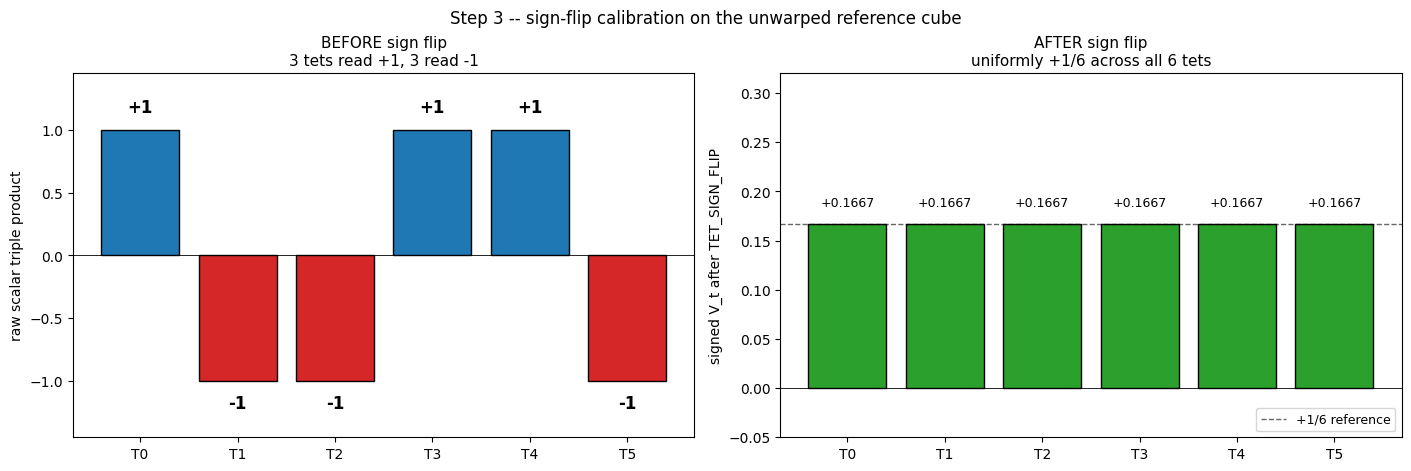

TET_SIGN_FLIP = [1.0, -1.0, -1.0, 1.0, 1.0, -1.0]


In [9]:
raws = np.array([_tet_compute(t)[0] for t in range(6)])
flipped = TET_SIGN_FLIP * raws / 6.0

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), layout='constrained')

# LEFT panel: raw scalar triple products (range +/-1).
bar_colors = ['#1f77b4' if r > 0 else '#d62728' for r in raws]
axes[0].bar(range(6), raws, color=bar_colors, edgecolor='black')
axes[0].axhline(0, color='black', lw=0.6)
axes[0].set_xticks(range(6))
axes[0].set_xticklabels(['T' + str(i) for i in range(6)])
axes[0].set_ylabel('raw scalar triple product')
axes[0].set_ylim(-1.45, 1.45)
axes[0].set_title('BEFORE sign flip\n3 tets read +1, 3 read -1', fontsize=11)
for i, r in enumerate(raws):
    # Place value labels well clear of the bar tops (no overlap with title).
    axes[0].text(i, r + (0.18 if r > 0 else -0.18),
                 ('+1' if r > 0 else '-1'),
                 ha='center', va='center', fontsize=12, fontweight='bold')

# RIGHT panel: sign-flipped values (all +1/6 ~= 0.1667).
axes[1].bar(range(6), flipped, color='#2ca02c', edgecolor='black')
axes[1].axhline(0, color='black', lw=0.6)
axes[1].axhline(1 / 6, color='black', linestyle='--', lw=1.0, alpha=0.6,
                label='+1/6 reference')
axes[1].set_xticks(range(6))
axes[1].set_xticklabels(['T' + str(i) for i in range(6)])
axes[1].set_ylabel('signed V_t after TET_SIGN_FLIP')
axes[1].set_ylim(-0.05, 0.32)
axes[1].set_title('AFTER sign flip\nuniformly +1/6 across all 6 tets', fontsize=11)
axes[1].legend(loc='lower right', fontsize=9)
for i, v in enumerate(flipped):
    axes[1].text(i, v + 0.022, format(v, '+.4f'),
                 ha='center', va='center', fontsize=9)

plt.suptitle('Step 3 -- sign-flip calibration on the unwarped reference cube',
             fontsize=12)
plt.show()

print('TET_SIGN_FLIP = ' + str(TET_SIGN_FLIP.tolist()))

In [10]:
# Variable packing follows dvfopt.core.solver3d._full_grid_step_3d:
# phi_flat = [dx_flat, dy_flat, dz_flat].

def tet_constraint_flat(phi_flat, grid_shape):
    """Flat 6 * (D-1) * (H-1) * (W-1) tet signed volumes for SLSQP."""
    D, H, W = grid_shape
    voxels = D * H * W
    dx = phi_flat[:voxels].reshape(D, H, W)
    dy = phi_flat[voxels:2 * voxels].reshape(D, H, W)
    dz = phi_flat[2 * voxels:].reshape(D, H, W)
    phi = np.stack([dz, dy, dx])
    return tet_signed_volumes(phi).flatten()


def jdet_constraint_flat(phi_flat, grid_shape):
    """Flat central-diff Jdet over the full grid (baseline S-CD constraint)."""
    D, H, W = grid_shape
    voxels = D * H * W
    dx = phi_flat[:voxels].reshape(D, H, W)
    dy = phi_flat[voxels:2 * voxels].reshape(D, H, W)
    dz = phi_flat[2 * voxels:].reshape(D, H, W)
    return _numpy_jdet_3d(dz, dy, dx).flatten()


def pack_phi(phi):
    """phi (3, D, H, W) -> flat [dx, dy, dz]."""
    return np.concatenate([phi[2].flatten(), phi[1].flatten(), phi[0].flatten()])


def unpack_phi(phi_flat, grid_shape):
    """flat [dx, dy, dz] -> phi (3, D, H, W)."""
    D, H, W = grid_shape
    voxels = D * H * W
    dx = phi_flat[:voxels].reshape(D, H, W)
    dy = phi_flat[voxels:2 * voxels].reshape(D, H, W)
    dz = phi_flat[2 * voxels:].reshape(D, H, W)
    return np.stack([dz, dy, dx])

In [11]:
rng = np.random.default_rng(0)
phi_rand = rng.standard_normal((3, 4, 5, 6))
flat = pack_phi(phi_rand)
phi_back = unpack_phi(flat, (4, 5, 6))
assert np.allclose(phi_back, phi_rand), 'pack/unpack roundtrip failed'

c_flat = tet_constraint_flat(flat, (4, 5, 6))
c_array = tet_signed_volumes(phi_rand).flatten()
assert np.allclose(c_flat, c_array), 'flat vs array form disagree'
assert c_flat.shape == (6 * 3 * 4 * 5,)

print(f'pack/unpack and constraint helpers OK  '
      f'(flat shape {flat.shape}, constraint shape {c_flat.shape})')

pack/unpack and constraint helpers OK  (flat shape (360,), constraint shape (360,))


## Test case 1 — 3D x-axis bowtie

The textbook 2D bowtie from `01_vs-central-diff.ipynb` (`dx[3,3]=+1.2, dx[3,4]=−1.2`) lifted to 3D by placing it in the middle z-slice of a 7×7×7 zero field.

Expected: central-diff Jdet stays all-positive (it's still a 2Δ stencil failure), but the tet check flags at least one cell with a negative tet volume.

In [12]:
def make_bowtie_x(D=7, H=7, W=7):
    phi = np.zeros((3, D, H, W))
    cz, cy, cx = D // 2, H // 2, W // 2
    phi[2, cz, cy, cx]     = +1.2  # dx
    phi[2, cz, cy, cx + 1] = -1.2
    return phi


phi_bx = make_bowtie_x()
j_bx = jacobian_det3D(phi_bx)
v_bx = tet_signed_volumes(phi_bx)

print('case 1 — 3D x-axis bowtie  (7x7x7)')
print(f'  central-diff Jdet  : min={j_bx.min():+.4f}  max={j_bx.max():+.4f}  n_neg={int((j_bx <= 0).sum())}')
print(f'  tet-volume check   : min={v_bx.min():+.4f}  max={v_bx.max():+.4f}  n_neg={int((v_bx <= 0).sum())}')
print(f'  cells with any neg tet: {int((v_bx.min(axis=0) <= 0).sum())}')

per_tet_neg = (v_bx <= 0).reshape(6, -1).sum(axis=1)
print(f'  per-tet neg counts  : {per_tet_neg.tolist()}  (T0..T5)')

case 1 — 3D x-axis bowtie  (7x7x7)
  central-diff Jdet  : min=+0.4000  max=+1.6000  n_neg=0
  tet-volume check   : min=-0.2333  max=+0.3667  n_neg=6
  cells with any neg tet: 4
  per-tet neg counts  : [1, 1, 1, 1, 1, 1]  (T0..T5)


In [13]:
# Canonical disagreement between central-diff and the tet check.
assert int((j_bx <= 0).sum()) == 0, 'central-diff should not detect this fold'
assert int((v_bx <= 0).sum()) >= 1, 'tet check must catch at least one flip'
print('case 1 disagreement confirmed: CD says clean, tet says folded')

case 1 disagreement confirmed: CD says clean, tet says folded


## Test cases 2 and 3 — z-axis bowtie + xy diagonal swap

**Case 2.** Same bowtie pattern, axis-rotated to z. Validates the 6-tet check is sensitive across all three axes (the body-diagonal choice could in principle bias detection toward folds aligned with one axis — running the same pattern on each axis tests that).

**Case 3.** A multi-axis fold: opposing displacements in both `dx` and `dy` between two adjacent y-rows. The fold is no longer aligned to a single axis; central-diff often still misses it, and we expect a different per-tet flip pattern.

In [14]:
def make_bowtie_z(D=7, H=7, W=7):
    phi = np.zeros((3, D, H, W))
    cz, cy, cx = D // 2, H // 2, W // 2
    phi[0, cz,     cy, cx] = +1.2  # dz
    phi[0, cz + 1, cy, cx] = -1.2
    return phi


def make_xy_diagonal(D=7, H=7, W=7):
    phi = np.zeros((3, D, H, W))
    cz, cy, cx = D // 2, H // 2, W // 2
    phi[2, cz, cy,     cx] = +0.8;  phi[1, cz, cy,     cx] = +0.8
    phi[2, cz, cy + 1, cx] = -0.8;  phi[1, cz, cy + 1, cx] = -0.8
    return phi


CASES = [
    ('case 1 -- x-axis bowtie',    make_bowtie_x()),
    ('case 2 -- z-axis bowtie',    make_bowtie_z()),
    ('case 3 -- xy diagonal swap', make_xy_diagonal()),
]

# --- non-zero displacement entries used to construct each case ---
CHAN_NAMES = ['dz', 'dy', 'dx']  # phi axis 0=dz, 1=dy, 2=dx

print('Construction-time non-zero displacement entries per case')
print('=' * 60)
for name, phi in CASES:
    D, H, W = phi.shape[1:]
    print()
    print(name + '   (D, H, W) = (' + str(D) + ', ' + str(H) + ', ' + str(W) + ')')
    nz = np.argwhere(phi != 0)
    if nz.size == 0:
        print('  (no non-zero entries)')
        continue
    # Sort by channel then voxel for readable printout.
    order = np.lexsort((nz[:, 3], nz[:, 2], nz[:, 1], nz[:, 0]))
    for k in order:
        ch, z, y, x = nz[k]
        val = float(phi[ch, z, y, x])
        print('  ' + CHAN_NAMES[ch] + '[z=' + str(int(z)) + ', y=' + str(int(y))
              + ', x=' + str(int(x)) + '] = ' + format(val, '+.3f'))

# --- CD vs tet diagnostics (existing comparison table) ---
print()
print('Detection diagnostics (central-diff Jdet vs 6-tet check)')
print('-' * 95)
print(f"{'case':<32s}  {'CD min':>9s}  {'CD n_neg':>9s}  "
      f"{'tet min':>9s}  {'tet n_neg':>10s}  {'cells_folded':>13s}")
print('-' * 95)
for name, phi in CASES:
    j = jacobian_det3D(phi)
    v = tet_signed_volumes(phi)
    cells_folded = int((v.min(axis=0) <= 0).sum())
    print(f'{name:<32s}  {j.min():+9.4f}  {int((j<=0).sum()):>9d}  '
          f'{v.min():+9.4f}  {int((v<=0).sum()):>10d}  {cells_folded:>13d}')

Construction-time non-zero displacement entries per case

case 1 -- x-axis bowtie   (D, H, W) = (7, 7, 7)
  dx[z=3, y=3, x=3] = +1.200
  dx[z=3, y=3, x=4] = -1.200

case 2 -- z-axis bowtie   (D, H, W) = (7, 7, 7)
  dz[z=3, y=3, x=3] = +1.200
  dz[z=4, y=3, x=3] = -1.200

case 3 -- xy diagonal swap   (D, H, W) = (7, 7, 7)
  dy[z=3, y=3, x=3] = +0.800
  dy[z=3, y=4, x=3] = -0.800
  dx[z=3, y=3, x=3] = +0.800
  dx[z=3, y=4, x=3] = -0.800

Detection diagnostics (central-diff Jdet vs 6-tet check)
-----------------------------------------------------------------------------------------------
case                                 CD min   CD n_neg    tet min   tet n_neg   cells_folded
-----------------------------------------------------------------------------------------------
case 1 -- x-axis bowtie             +0.4000          0    -0.2333           6              4
case 2 -- z-axis bowtie             +0.4000          0    -0.2333           6              4
case 3 -- xy diagonal swap      

In [15]:
for name, phi in CASES:
    v = tet_signed_volumes(phi)
    assert (v <= 0).any(), f'{name} produced no flip — case is invalid'
print('all 3 cases produce at least one flipped tet')

all 3 cases produce at least one flipped tet


## SLSQP correction — central-diff (S-CD) vs tet-volume (S-TET) constraint

Two solver runs per case:

- **S-CD** — full-grid SLSQP with `_numpy_jdet_3d ≥ THRESHOLD`. This is the existing approach in `dvfopt.core.solver3d._full_grid_step_3d`.
- **S-TET** — full-grid SLSQP with all 6 per-cell tet signed volumes `≥ THRESHOLD`.

Both use the L2 objective (`objective_euc`) starting from the folded `phi`.

The tet constraint vector for a `D × H × W` grid has length `6 · (D-1) · (H-1) · (W-1)`. On 7³ this is `6 · 6³ = 1296` constraints — manageable for SLSQP.

### S-TET constraints in detail

The optimisation solved for each test case is

$$
\min_{\phi}\; \tfrac{1}{2}\,\lVert \phi - \phi_{0} \rVert_{2}^{2}
\qquad \text{subject to}\qquad
V_{t}(c;\,\phi) \;\ge\; \tau
\quad \text{for every cell } c \text{ and every tet } t.
$$

**Variables.** $\phi$ is the flattened displacement field of length $3 \cdot D \cdot H \cdot W$, packed as $[\,\mathrm{dx}\,\mid\,\mathrm{dy}\,\mid\,\mathrm{dz}\,]$ (matching `dvfopt.core.solver3d._full_grid_step_3d`). $\phi_{0}$ is the folded input. $\tau = \mathtt{THRESHOLD} = 0.01$.

**Per-tet signed volume.** Cell $c$ has integer origin $(c_z,c_y,c_x)$ and 8 corners $p_{i} = (c_z+\delta z_i,\,c_y+\delta y_i,\,c_x+\delta x_i)$ for $i \in \{0,\dots,7\}$ from `CUBE_CORNERS`. The warped position of corner $i$ is

$$
\mathbf{x}_{i}^{\mathrm{w}}(\phi) \;=\; \bigl(\,c_x + \delta x_i + \mathrm{dx}[p_i],\ \ c_y + \delta y_i + \mathrm{dy}[p_i],\ \ c_z + \delta z_i + \mathrm{dz}[p_i]\,\bigr).
$$

For tet $t \in \{T_0,\dots,T_5\}$ with vertex indices $(i_a, i_b, i_c, i_d)$ from `TET_INDICES`, write the warped corners as $\mathbf{a},\mathbf{b},\mathbf{c},\mathbf{d}$ for short. The signed volume is

$$
V_{t}(c;\,\phi) \;=\; \frac{s_{t}}{6}\;
\bigl(\mathbf{b}-\mathbf{a}\bigr) \,\cdot\, \bigl[\,(\mathbf{c}-\mathbf{a})\times(\mathbf{d}-\mathbf{a})\,\bigr].
$$

The factor $s_{t} \in \{+1,-1\}$ is the entry of `TET_SIGN_FLIP`. It is needed because half of the six monotone-path orderings $(v_0,A,B,v_7)$ are even permutations of the cube's vertices and half are odd, so the raw scalar triple product is positive on three tets of the unwarped cube and negative on three. Calibrating $s$ once on the identity field (`_calibrate_sign_flip`) makes every $V_t$ unambiguously *positive on a valid cell*, so the single uniform inequality $V_t \ge \tau$ correctly excludes folds for all six tets.

**One constraint per (cell, tet).** Stacking over every interior cell of the grid and every tet of its decomposition gives a vector-valued constraint of length

$$
N_{\text{constr}} \;=\; 6 \,\cdot\, (D-1)(H-1)(W-1).
$$

For the $7^{3}$ test cases this is $6 \cdot 6^{3} = 1296$ scalar constraints over $3 \cdot 7^{3} = 1029$ variables. (The 2D analog in `triangle_sign_constraint` uses $2\cdot(H-1)(W-1)$ constraints — same shape, one diagonal per cell, two simplices per cell.)

**Why this is well-posed for SLSQP.** Each $V_t$ is a polynomial of degree 3 in the displacement components — smooth and infinitely differentiable. SLSQP's quasi-Newton update needs only the constraint values and a Jacobian; we hand it the values via `tet_constraint_flat` and let scipy estimate the Jacobian by finite differences (the small problem size makes this fine; promoting this to `iterative_3d` for production-scale grids would want an analytic Jacobian, mirroring `gradients3d.jdet_constraint_jacobian_3d`).

**Geometric meaning of the constraint.**

| sign of $V_t$ | what it means geometrically |
|---|---|
| $V_t \ge \tau$ | tet is non-degenerate and oriented like the unwarped reference (valid). |
| $0 \le V_t < \tau$ | tet is valid but thin — within the safety margin near collapse. |
| $V_t = 0$ | tet has collapsed to a plane (4 coplanar corners). |
| $V_t < 0$ | tet has *inverted* — its 4 warped corners trace the opposite handedness from the reference. This is the local 3D analog of the bowtie. |

A cell is fold-free iff all 6 of its tets satisfy $V_t \ge \tau$. The S-TET solver makes this hold simultaneously for every cell. Contrast S-CD, which imposes *one* central-difference Jdet $\ge \tau$ per voxel — an averaged 9-partial quantity that can stay positive while individual tets in the same cell are inverted, exactly the failure mode the per-tet constraint is designed to close.

In [16]:
def run_slsqp(phi_anchor, constraint_kind, max_iter=200, threshold=THRESHOLD):
    """Full-grid SLSQP with either central-diff or tet-volume constraints."""
    grid_shape = phi_anchor.shape[1:]
    z0 = pack_phi(phi_anchor)

    if constraint_kind == 'cd':
        constr = NonlinearConstraint(
            lambda z: jdet_constraint_flat(z, grid_shape),
            lb=threshold, ub=np.inf,
        )
    elif constraint_kind == 'tet':
        constr = NonlinearConstraint(
            lambda z: tet_constraint_flat(z, grid_shape),
            lb=threshold, ub=np.inf,
        )
    else:
        raise ValueError(constraint_kind)

    t0 = time.time()
    res = minimize(
        lambda z: objective_euc(z, z0),
        z0.copy(), jac=True, method='SLSQP',
        constraints=[constr],
        options={'maxiter': max_iter, 'disp': False},
    )
    elapsed = time.time() - t0
    phi_out = unpack_phi(res.x, grid_shape)
    j_out = jacobian_det3D(phi_out)
    v_out = tet_signed_volumes(phi_out)
    return {
        'phi': phi_out,
        'l2': float(np.linalg.norm(phi_out - phi_anchor)),
        'n_neg_cd':  int((j_out <= 0).sum()),
        'n_neg_tet': int((v_out <= 0).sum()),
        'min_cd':  float(j_out.min()),
        'min_tet': float(v_out.min()),
        'nit': res.nit,
        't': elapsed,
        'success': bool(res.success),
        'status': int(res.status),
    }


print('Running SLSQP on each case (this takes ~30s total on 7^3)...')
slsqp_results = {}
for name, phi in CASES:
    print(f'  {name}', flush=True)
    r_cd  = run_slsqp(phi, 'cd',  max_iter=200)
    print(f'    S-CD : nit={r_cd["nit"]:3d}  t={r_cd["t"]:5.2f}s  '
          f'L2={r_cd["l2"]:6.3f}  n_neg_cd={r_cd["n_neg_cd"]:3d}  '
          f'n_neg_tet={r_cd["n_neg_tet"]:3d}  min_tet={r_cd["min_tet"]:+.3f}  ok={r_cd["success"]}',
          flush=True)
    r_tet = run_slsqp(phi, 'tet', max_iter=200)
    print(f'    S-TET: nit={r_tet["nit"]:3d}  t={r_tet["t"]:5.2f}s  '
          f'L2={r_tet["l2"]:6.3f}  n_neg_cd={r_tet["n_neg_cd"]:3d}  '
          f'n_neg_tet={r_tet["n_neg_tet"]:3d}  min_tet={r_tet["min_tet"]:+.3f}  ok={r_tet["success"]}',
          flush=True)
    slsqp_results[name] = {'phi_init': phi, 'cd': r_cd, 'tet': r_tet}

Running SLSQP on each case (this takes ~30s total on 7^3)...
  case 1 -- x-axis bowtie


    S-CD : nit=  1  t= 0.90s  L2= 0.000  n_neg_cd=  0  n_neg_tet=  6  min_tet=-0.233  ok=True


    S-TET: nit=  8  t= 5.97s  L2= 0.959  n_neg_cd=  0  n_neg_tet=  0  min_tet=+0.010  ok=True


  case 2 -- z-axis bowtie


    S-CD : nit=  1  t= 0.50s  L2= 0.000  n_neg_cd=  0  n_neg_tet=  6  min_tet=-0.233  ok=True


    S-TET: nit=  8  t= 7.11s  L2= 0.959  n_neg_cd=  0  n_neg_tet=  0  min_tet=+0.010  ok=True


  case 3 -- xy diagonal swap


    S-CD : nit=  1  t= 0.93s  L2= 0.000  n_neg_cd=  0  n_neg_tet=  2  min_tet=-0.100  ok=True


    S-TET: nit=  5  t= 5.04s  L2= 0.282  n_neg_cd=  0  n_neg_tet=  0  min_tet=+0.010  ok=True


In [17]:
print(f"{'case':<32s}  {'solver':<6s}  {'nit':>4s}  {'time':>6s}  "
      f"{'L2':>7s}  {'min_CD':>8s}  {'min_TET':>8s}  {'n_neg_TET':>10s}  ok")
print('-' * 102)
for name in [n for n, _ in CASES]:
    for tag in ('cd', 'tet'):
        r = slsqp_results[name][tag]
        print(f'{name:<32s}  S-{tag.upper():<4s}  {r["nit"]:>4d}  {r["t"]:>6.2f}  '
              f'{r["l2"]:>7.3f}  {r["min_cd"]:+8.3f}  {r["min_tet"]:+8.3f}  '
              f'{r["n_neg_tet"]:>10d}  {r["success"]}')

case                              solver   nit    time       L2    min_CD   min_TET   n_neg_TET  ok
------------------------------------------------------------------------------------------------------
case 1 -- x-axis bowtie           S-CD       1    0.90    0.000    +0.400    -0.233           6  True
case 1 -- x-axis bowtie           S-TET      8    5.97    0.959    +0.709    +0.010           0  True
case 2 -- z-axis bowtie           S-CD       1    0.50    0.000    +0.400    -0.233           6  True
case 2 -- z-axis bowtie           S-TET      8    7.11    0.959    +0.709    +0.010           0  True
case 3 -- xy diagonal swap        S-CD       1    0.93    0.000    +0.600    -0.100           2  True
case 3 -- xy diagonal swap        S-TET      5    5.04    0.282    +0.586    +0.010           0  True


In [18]:
# Spec criterion 4: S-TET reaches min_tet >= THRESHOLD where S-CD does not,
# on at least one case.
TOL = 1e-6
n_strictly_better = 0
for name, _ in CASES:
    r_cd  = slsqp_results[name]['cd']
    r_tet = slsqp_results[name]['tet']
    cd_clean  = r_cd['min_tet']  >= THRESHOLD - TOL
    tet_clean = r_tet['min_tet'] >= THRESHOLD - TOL
    if tet_clean and not cd_clean:
        n_strictly_better += 1
print(f'cases where S-TET reaches min_tet >= THRESHOLD but S-CD does NOT: '
      f'{n_strictly_better} / {len(CASES)}')
assert n_strictly_better >= 1, 'expected S-TET to strictly beat S-CD on ≥1 case'

cases where S-TET reaches min_tet >= THRESHOLD but S-CD does NOT: 3 / 3


### Step 4 — visualise the SLSQP constraint `V_t \u2265 \u03c4` in action

Plug a folded `\u03c6` into the per-cell tet check: one or more of the 6 volumes goes negative — the cell is folded. SLSQP minimises L2 distance to the original `\u03c6` while constraining every per-cell tet volume to be at least `\u03c4 = 0.01`. After convergence, every bar in every cell sits **on or above** the threshold line.

For each test case, we pick the worst-folded cell and show its 6 tet volumes side-by-side: INITIAL (left) and S-TET CORRECTED (right). Bars colour-coded:

- **Red** — `V_t < 0` (folded).
- **Yellow** — `0 \u2264 V_t < \u03c4` (within margin, infeasible).
- **Green** — `V_t \u2265 \u03c4` (constraint satisfied).

Bars sitting exactly on the dashed `\u03c4` line in the corrected panel are *active* constraints — these are the ones the optimiser is holding to the threshold; whichever bars sit well above are inactive.

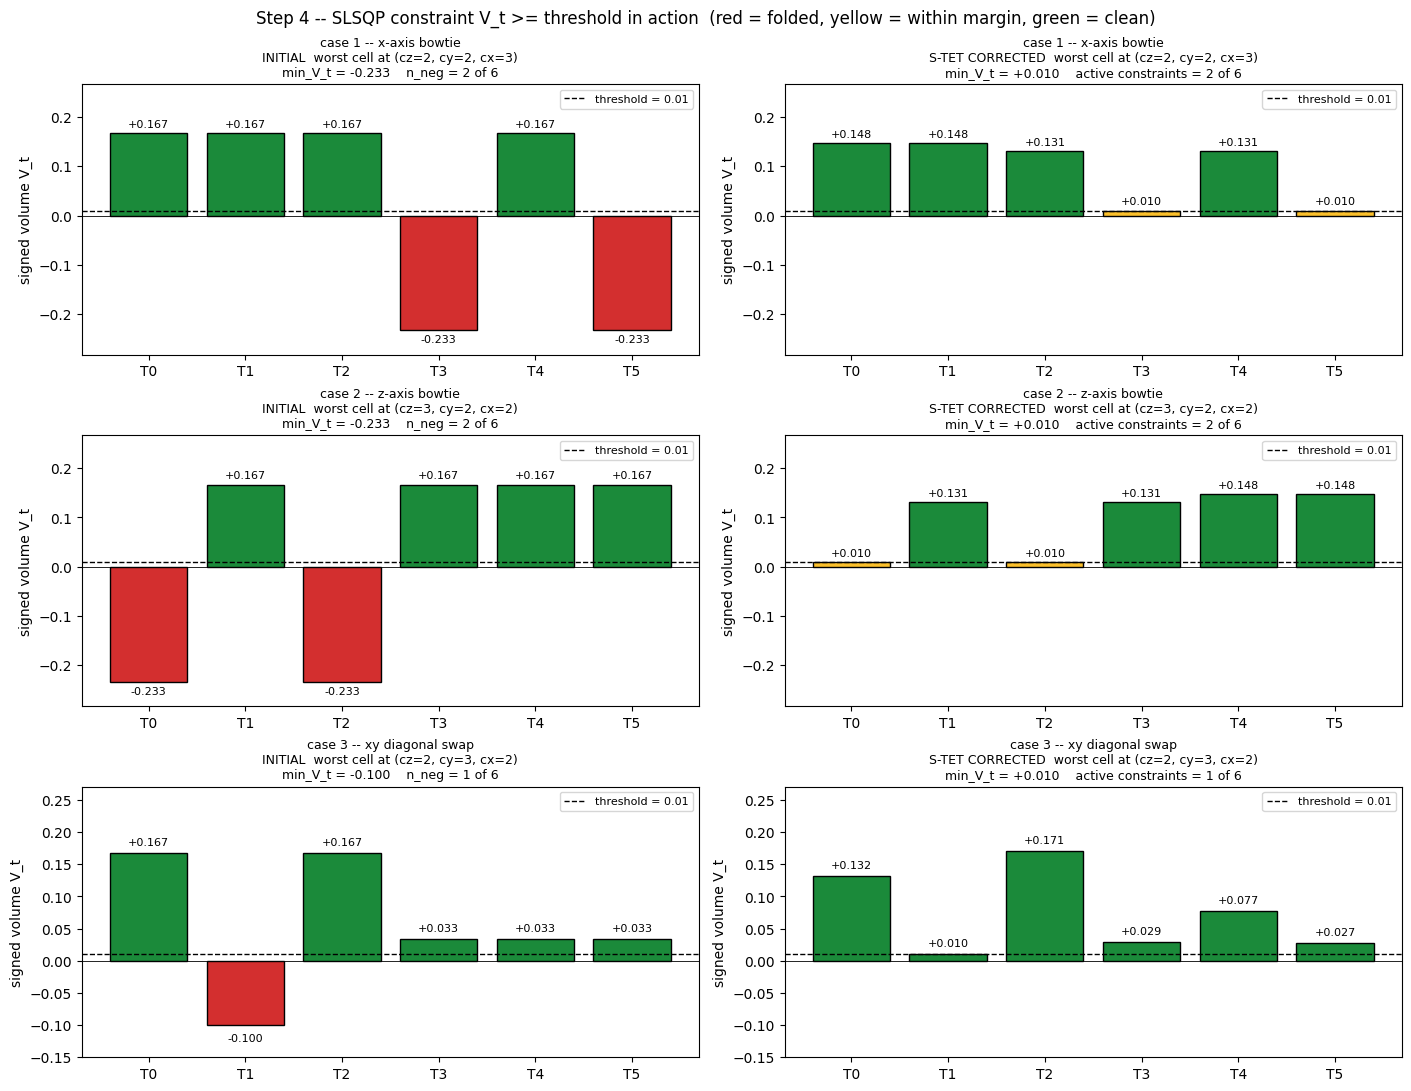

In [19]:
def _worst_cell(phi):
    cell_min = tet_signed_volumes(phi).min(axis=0)
    return tuple(int(c) for c in np.unravel_index(int(np.argmin(cell_min)), cell_min.shape))


def _bar_colors(values, threshold):
    return ['#d32f2f' if v < 0 else
            '#fbc02c' if v < threshold else
            '#1b8a3a' for v in values]


fig, axes = plt.subplots(len(CASES), 2, figsize=(14, 3.6 * len(CASES)),
                          layout='constrained', squeeze=False)

for i, (name, phi) in enumerate(CASES):
    cz, cy, cx = _worst_cell(phi)
    V_init = tet_signed_volumes(phi)[:, cz, cy, cx]
    phi_corr = slsqp_results[name]['tet']['phi']
    V_corr = tet_signed_volumes(phi_corr)[:, cz, cy, cx]

    lo = min(float(V_init.min()), float(V_corr.min()), 0.0) - 0.05
    hi = max(float(V_init.max()), float(V_corr.max()), THRESHOLD) + 0.10

    panels = [('INITIAL', V_init), ('S-TET CORRECTED', V_corr)]
    for col, (label, V) in enumerate(panels):
        ax = axes[i, col]
        ax.bar(range(6), V, color=_bar_colors(V, THRESHOLD), edgecolor='black')
        ax.axhline(THRESHOLD, color='black', linestyle='--', lw=1.0,
                   label='threshold = ' + str(THRESHOLD))
        ax.axhline(0, color='black', lw=0.6)
        ax.set_xticks(range(6))
        ax.set_xticklabels(['T' + str(k) for k in range(6)])
        ax.set_ylabel('signed volume V_t')
        ax.set_ylim(lo, hi)
        n_neg = int((V <= 0).sum())
        n_active = int((np.abs(V - THRESHOLD) < 1e-4).sum())
        if col == 0:
            sub = ('min_V_t = ' + format(float(V.min()), '+.3f') +
                   '    n_neg = ' + str(n_neg) + ' of 6')
        else:
            sub = ('min_V_t = ' + format(float(V.min()), '+.3f') +
                   '    active constraints = ' + str(n_active) + ' of 6')
        ax.set_title(name + chr(10) +
                     label + '  worst cell at (cz=' + str(cz) +
                     ', cy=' + str(cy) + ', cx=' + str(cx) + ')' + chr(10) + sub,
                     fontsize=9)
        ax.legend(loc='upper right', fontsize=8)
        for k, v in enumerate(V):
            ax.text(k, v + (0.012 if v >= 0 else -0.025),
                    format(float(v), '+.3f'), ha='center', fontsize=8)

plt.suptitle('Step 4 -- SLSQP constraint V_t >= threshold in action  '
             '(red = folded, yellow = within margin, green = clean)',
             fontsize=12)
plt.show()

## Visualisation helpers

In [20]:
def fold_bbox_3d(fold_mask, shape, pad=1):
    """Return (z_lo, z_hi, y_lo, y_hi, x_lo, x_hi) corner-coord bbox of a
    cell-level fold mask of shape (D-1, H-1, W-1), with `pad` voxels of
    padding clamped to [0, dim-1]. Returns None if mask is empty.
    """
    if not fold_mask.any():
        return None
    cells = np.argwhere(fold_mask)
    cz_min, cy_min, cx_min = cells.min(axis=0)
    cz_max, cy_max, cx_max = cells.max(axis=0)
    D, H, W = shape
    z_lo = max(cz_min - pad, 0); z_hi = min(cz_max + 1 + pad, D - 1)
    y_lo = max(cy_min - pad, 0); y_hi = min(cy_max + 1 + pad, H - 1)
    x_lo = max(cx_min - pad, 0); x_hi = min(cx_max + 1 + pad, W - 1)
    return (z_lo, z_hi, y_lo, y_hi, x_lo, x_hi)


def fold_centroid_3d(fold_mask):
    """Return integer (cz, cy, cx) centroid (cell indices) of folded cells.
    None if mask is empty."""
    if not fold_mask.any():
        return None
    cells = np.argwhere(fold_mask)
    return tuple(int(round(c)) for c in cells.mean(axis=0))


def plot_warped_grid_3d(ax, phi, title, *, outline_mask=None,
                        outline_color='#d32f2f', outline_lw=1.6,
                        zoom_mask=None, zoom_pad=1,
                        edge_alpha=0.55, ref_alpha=0.05):
    """Render a warped voxel grid in 3D, outlining specified cells.

    By default outlines cells where `min(T0..T5) <= 0`. Pass `outline_mask`
    to override which cells get outlined (e.g. highlight originally-folded
    cells in green on a corrected field). Pass `zoom_mask` to limit the
    axis ranges to the bbox of those cells (+ padding); useful for
    inspecting the small folded region inside a larger grid.
    """
    D, H, W = phi.shape[1:]
    corners = warp_corners(phi)
    ref = warp_corners(np.zeros_like(phi))

    for axis in range(3):
        dims = [d for i, d in enumerate((D, H, W)) if i != axis]
        for slc in np.ndindex(*dims):
            sl = list(slc); sl.insert(axis, slice(None))
            seg = ref[tuple(sl)]
            ax.plot(seg[..., 0], seg[..., 1], seg[..., 2],
                    color='gray', lw=0.3, alpha=ref_alpha)

    for axis in range(3):
        dims = [d for i, d in enumerate((D, H, W)) if i != axis]
        for slc in np.ndindex(*dims):
            sl = list(slc); sl.insert(axis, slice(None))
            seg = corners[tuple(sl)]
            ax.plot(seg[..., 0], seg[..., 1], seg[..., 2],
                    color='#5b7fb5', lw=0.7, alpha=edge_alpha)

    mask = outline_mask if outline_mask is not None else (tet_min_per_cell(phi) <= 0)
    if mask is not None and mask.any():
        edges = [
            ((0,0,0),(0,0,1)),((0,1,0),(0,1,1)),((1,0,0),(1,0,1)),((1,1,0),(1,1,1)),
            ((0,0,0),(0,1,0)),((0,0,1),(0,1,1)),((1,0,0),(1,1,0)),((1,0,1),(1,1,1)),
            ((0,0,0),(1,0,0)),((0,0,1),(1,0,1)),((0,1,0),(1,1,0)),((0,1,1),(1,1,1)),
        ]
        for (cz, cy, cx) in np.argwhere(mask):
            for (a, b) in edges:
                p = corners[cz + a[0], cy + a[1], cx + a[2]]
                q = corners[cz + b[0], cy + b[1], cx + b[2]]
                ax.plot([p[0], q[0]], [p[1], q[1]], [p[2], q[2]],
                        color=outline_color, lw=outline_lw)

    if zoom_mask is not None:
        bbox = fold_bbox_3d(zoom_mask, (D, H, W), pad=zoom_pad)
        if bbox is not None:
            z_lo, z_hi, y_lo, y_hi, x_lo, x_hi = bbox
            ax.set_xlim(x_lo, x_hi)
            ax.set_ylim(y_lo, y_hi)
            ax.set_zlim(z_lo, z_hi)
            ax.set_box_aspect((max(x_hi - x_lo, 1),
                               max(y_hi - y_lo, 1),
                               max(z_hi - z_lo, 1)))
        else:
            ax.set_box_aspect((W, H, D))
    else:
        ax.set_box_aspect((W, H, D))

    ax.set_title(title, fontsize=9)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')


def plot_warped_slice_2d(ax, phi, axis, slice_idx, *, outline_mask_3d=None,
                          outline_color='#d32f2f', outline_lw=2.0,
                          warp_color='#5b7fb5', warp_lw=0.9,
                          ref_color='#dddddd', ref_lw=0.4,
                          title='', zoom_to_outline=True, zoom_pad=1):
    """Draw a 2D warped quad grid for an orthogonal slice through phi.

    axis : 'xy' (z fixed), 'xz' (y fixed), or 'yz' (x fixed).
    slice_idx : voxel index along the fixed axis.
    outline_mask_3d : (D-1, H-1, W-1) bool — a 2D quad in the slice is
        outlined iff at least one of the (up to two) 3D cells whose face
        equals that quad is True in the mask.
    """
    D, H, W = phi.shape[1:]
    dz, dy, dx = phi[0], phi[1], phi[2]

    if axis == 'xy':
        z0 = slice_idx
        a_size, b_size = H, W
        gx = np.broadcast_to(np.arange(W), (H, W)).astype(float) + dx[z0]
        gy = np.broadcast_to(np.arange(H)[:, None], (H, W)).astype(float) + dy[z0]
        ref_x = np.broadcast_to(np.arange(W), (H, W)).astype(float)
        ref_y = np.broadcast_to(np.arange(H)[:, None], (H, W)).astype(float)
        a_label, b_label = 'y', 'x'
    elif axis == 'xz':
        y0 = slice_idx
        a_size, b_size = D, W
        gx = np.broadcast_to(np.arange(W), (D, W)).astype(float) + dx[:, y0, :]
        gy = np.broadcast_to(np.arange(D)[:, None], (D, W)).astype(float) + dz[:, y0, :]
        ref_x = np.broadcast_to(np.arange(W), (D, W)).astype(float)
        ref_y = np.broadcast_to(np.arange(D)[:, None], (D, W)).astype(float)
        a_label, b_label = 'z', 'x'
    elif axis == 'yz':
        x0 = slice_idx
        a_size, b_size = D, H
        gx = np.broadcast_to(np.arange(H), (D, H)).astype(float) + dy[:, :, x0]
        gy = np.broadcast_to(np.arange(D)[:, None], (D, H)).astype(float) + dz[:, :, x0]
        ref_x = np.broadcast_to(np.arange(H), (D, H)).astype(float)
        ref_y = np.broadcast_to(np.arange(D)[:, None], (D, H)).astype(float)
        a_label, b_label = 'z', 'y'
    else:
        raise ValueError(f'axis must be xy/xz/yz, got {axis!r}')

    for i in range(a_size):
        ax.plot(ref_x[i], ref_y[i], color=ref_color, lw=ref_lw)
    for j in range(b_size):
        ax.plot(ref_x[:, j], ref_y[:, j], color=ref_color, lw=ref_lw)
    for i in range(a_size):
        ax.plot(gx[i], gy[i], color=warp_color, lw=warp_lw)
    for j in range(b_size):
        ax.plot(gx[:, j], gy[:, j], color=warp_color, lw=warp_lw)

    mask_2d = None
    if outline_mask_3d is not None:
        m3 = outline_mask_3d
        D_c, H_c, W_c = m3.shape
        mask_2d = np.zeros((a_size - 1, b_size - 1), dtype=bool)
        if axis == 'xy':
            for cz_3d in (slice_idx - 1, slice_idx):
                if 0 <= cz_3d < D_c:
                    mask_2d |= m3[cz_3d]
        elif axis == 'xz':
            for cy_3d in (slice_idx - 1, slice_idx):
                if 0 <= cy_3d < H_c:
                    mask_2d |= m3[:, cy_3d, :]
        else:
            for cx_3d in (slice_idx - 1, slice_idx):
                if 0 <= cx_3d < W_c:
                    mask_2d |= m3[:, :, cx_3d]

        for (ci, cj) in np.argwhere(mask_2d):
            poly_x = [gx[ci, cj], gx[ci, cj+1], gx[ci+1, cj+1], gx[ci+1, cj], gx[ci, cj]]
            poly_y = [gy[ci, cj], gy[ci, cj+1], gy[ci+1, cj+1], gy[ci+1, cj], gy[ci, cj]]
            ax.plot(poly_x, poly_y, color=outline_color, lw=outline_lw)

    if zoom_to_outline and mask_2d is not None and mask_2d.any():
        cells = np.argwhere(mask_2d)
        ci_min, cj_min = cells.min(axis=0)
        ci_max, cj_max = cells.max(axis=0)
        i_lo = max(ci_min - zoom_pad, 0); i_hi = min(ci_max + 1 + zoom_pad, a_size - 1)
        j_lo = max(cj_min - zoom_pad, 0); j_hi = min(cj_max + 1 + zoom_pad, b_size - 1)
        ax.set_xlim(j_lo - 0.3, j_hi + 0.3)
        ax.set_ylim(i_hi + 0.3, i_lo - 0.3)
    else:
        ax.invert_yaxis()

    ax.set_aspect('equal')
    ax.set_xlabel(b_label, fontsize=8)
    ax.set_ylabel(a_label, fontsize=8)
    ax.set_title(title, fontsize=8)


def plot_midz_heatmaps(axes, phi, label):
    """Plot mid-z slice of central-diff Jdet (left) and min-tet volume (right)."""
    D = phi.shape[1]
    cz = D // 2
    j = jacobian_det3D(phi)
    v = tet_min_per_cell(phi)
    vmax_j = max(abs(j[cz]).max(), 1e-3)
    cz_v = min(cz, v.shape[0] - 1)
    vmax_v = max(abs(v[cz_v]).max(), 1e-3)
    im0 = axes[0].imshow(j[cz], cmap='RdBu_r', vmin=-vmax_j, vmax=vmax_j)
    axes[0].set_title(f'{label} — central-diff Jdet (z={cz})\n'
                      f'min={j[cz].min():+.3f}  n_neg={int((j[cz] <= 0).sum())}', fontsize=8)
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    im1 = axes[1].imshow(v[cz_v], cmap='RdBu_r', vmin=-vmax_v, vmax=vmax_v)
    axes[1].set_title(f'{label} — min(T0..T5) (z={cz_v})\n'
                      f'min={v.min():+.3f}  n_cells_neg={int((v <= 0).sum())}', fontsize=8)
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    for a in axes:
        a.set_xticks([]); a.set_yticks([])


def plot_per_tet_bars(ax, phi, label):
    v = tet_signed_volumes(phi)
    counts = (v <= 0).reshape(6, -1).sum(axis=1)
    ax.bar(range(6), counts, color='#5b7fb5', edgecolor='k')
    ax.set_xticks(range(6))
    ax.set_xticklabels([f'T{i}' for i in range(6)], fontsize=8)
    ax.set_title(f'{label} — per-tet flip count', fontsize=9)
    ax.set_ylabel('# cells with V <= 0', fontsize=8)


def best_slice_idx(phi, axis):
    """Pick the voxel index along the fixed axis with the largest total
    displacement magnitude (sum over |dz|+|dy|+|dx| in that slice).

    For an x-axis bowtie (dx non-zero only at z=3), this returns z=3 for
    axis='xy', so the chosen slice actually contains the fold rather than
    the cell-fold-mask centroid (which would land between z=2 and z=3 and
    round to z=2, where the slice is undeformed).
    """
    abs_phi = np.abs(phi).sum(axis=0)  # (D, H, W)
    if axis == 'xy':   # fix z
        return int(np.argmax(abs_phi.sum(axis=(1, 2))))
    if axis == 'xz':   # fix y
        return int(np.argmax(abs_phi.sum(axis=(0, 2))))
    if axis == 'yz':   # fix x
        return int(np.argmax(abs_phi.sum(axis=(0, 1))))
    raise ValueError(axis)


def slice_inplane_disp(phi, axis, slice_idx):
    """Max |displacement| in the *projection plane* of this 2D slice. If 0,
    the slice's warped grid equals the unwarped grid and no fold geometry
    is visible there (the displacement is orthogonal to the slice plane)."""
    dz, dy, dx = phi[0], phi[1], phi[2]
    if axis == 'xy':
        return float(max(np.abs(dx[slice_idx]).max(), np.abs(dy[slice_idx]).max()))
    if axis == 'xz':
        return float(max(np.abs(dx[:, slice_idx, :]).max(), np.abs(dz[:, slice_idx, :]).max()))
    if axis == 'yz':
        return float(max(np.abs(dy[:, :, slice_idx]).max(), np.abs(dz[:, :, slice_idx]).max()))
    raise ValueError(axis)


def slice_2d_tri_min(phi, axis, slice_idx):
    """Per-slice 2D bowtie check: minimum of the 2-triangle TR-BL signed
    areas over every projected quad in the slice. Returns (min, n_neg).

    A negative value means the 2D projection contains a self-intersecting
    quad. This is the exact same check `triangle_sign_areas2D` uses in 2D,
    just applied to the projection of the 3D field.
    """
    dz, dy, dx = phi[0], phi[1], phi[2]
    D, H, W = dz.shape
    if axis == 'xy':
        z0 = slice_idx
        gx = np.broadcast_to(np.arange(W), (H, W)).astype(float) + dx[z0]
        gy = np.broadcast_to(np.arange(H)[:, None], (H, W)).astype(float) + dy[z0]
    elif axis == 'xz':
        y0 = slice_idx
        gx = np.broadcast_to(np.arange(W), (D, W)).astype(float) + dx[:, y0, :]
        gy = np.broadcast_to(np.arange(D)[:, None], (D, W)).astype(float) + dz[:, y0, :]
    elif axis == 'yz':
        x0 = slice_idx
        gx = np.broadcast_to(np.arange(H), (D, H)).astype(float) + dy[:, :, x0]
        gy = np.broadcast_to(np.arange(D)[:, None], (D, H)).astype(float) + dz[:, :, x0]
    else:
        raise ValueError(axis)

    x_tl, y_tl = gx[:-1, :-1], gy[:-1, :-1]
    x_tr, y_tr = gx[:-1, 1:],  gy[:-1, 1:]
    x_bl, y_bl = gx[1:, :-1],  gy[1:, :-1]
    x_br, y_br = gx[1:, 1:],   gy[1:, 1:]
    T1 = -0.5 * ((x_bl - x_tr) * (y_br - y_tr) - (y_bl - y_tr) * (x_br - x_tr))
    T2 = -0.5 * ((x_bl - x_tl) * (y_tr - y_tl) - (y_bl - y_tl) * (x_tr - x_tl))
    tri_min = np.minimum(T1, T2)
    return float(tri_min.min()), int((tri_min <= 0).sum())


def slice_3d_tet_min(phi, axis, slice_idx):
    """Per-slice 3D check: minimum tet signed volume across the (up to 2)
    layers of 3D cells whose face lies in this slice plane.

    This is the truthful 3D-fold status for cells visible in the slice; an
    apparent 2D crossing with `slice_3d_tet_min >= THRESHOLD` is a pure
    projection artefact (out-of-plane dz/dy/dx tilt).
    """
    v = tet_signed_volumes(phi)  # (6, D-1, H-1, W-1)
    D_c, H_c, W_c = v.shape[1:]
    layers = []
    if axis == 'xy':
        for c in (slice_idx - 1, slice_idx):
            if 0 <= c < D_c:
                layers.append(v[:, c, :, :])
    elif axis == 'xz':
        for c in (slice_idx - 1, slice_idx):
            if 0 <= c < H_c:
                layers.append(v[:, :, c, :])
    elif axis == 'yz':
        for c in (slice_idx - 1, slice_idx):
            if 0 <= c < W_c:
                layers.append(v[:, :, :, c])
    else:
        raise ValueError(axis)
    if not layers:
        return float('inf')
    return float(np.concatenate([l.ravel() for l in layers]).min())


# Smoke test that helpers run without raising.
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='3d')
plot_warped_grid_3d(ax, make_bowtie_x(D=5, H=5, W=5), 'smoke')
plt.close(fig)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), layout='constrained')
plot_midz_heatmaps(axes, make_bowtie_x(D=5, H=5, W=5), 'smoke')
plt.close(fig)
fig, ax = plt.subplots(figsize=(3, 3))
plot_warped_slice_2d(ax, make_bowtie_x(D=5, H=5, W=5), 'xy', 2,
                      outline_mask_3d=tet_min_per_cell(make_bowtie_x(D=5, H=5, W=5)) <= 0)
plt.close(fig)
print('viz helpers run without errors')

viz helpers run without errors


## Per-case visualisation

Each row is one case. Columns:

1. **3D warped grid (initial)** — cells with any flipped tet outlined in dark red.
2. **3D warped grid (S-TET corrected)** — the *same cells from column 1* (i.e. the originally-folded cells) outlined in bold green, so the eye can locate the same region in the corrected field. No flipped tets remain.
3. **Mid-z central-diff Jdet** for the initial field.
4. **Mid-z min-tet volume** for the initial field.
5. **Per-tet flip count bar chart** (T0..T5).

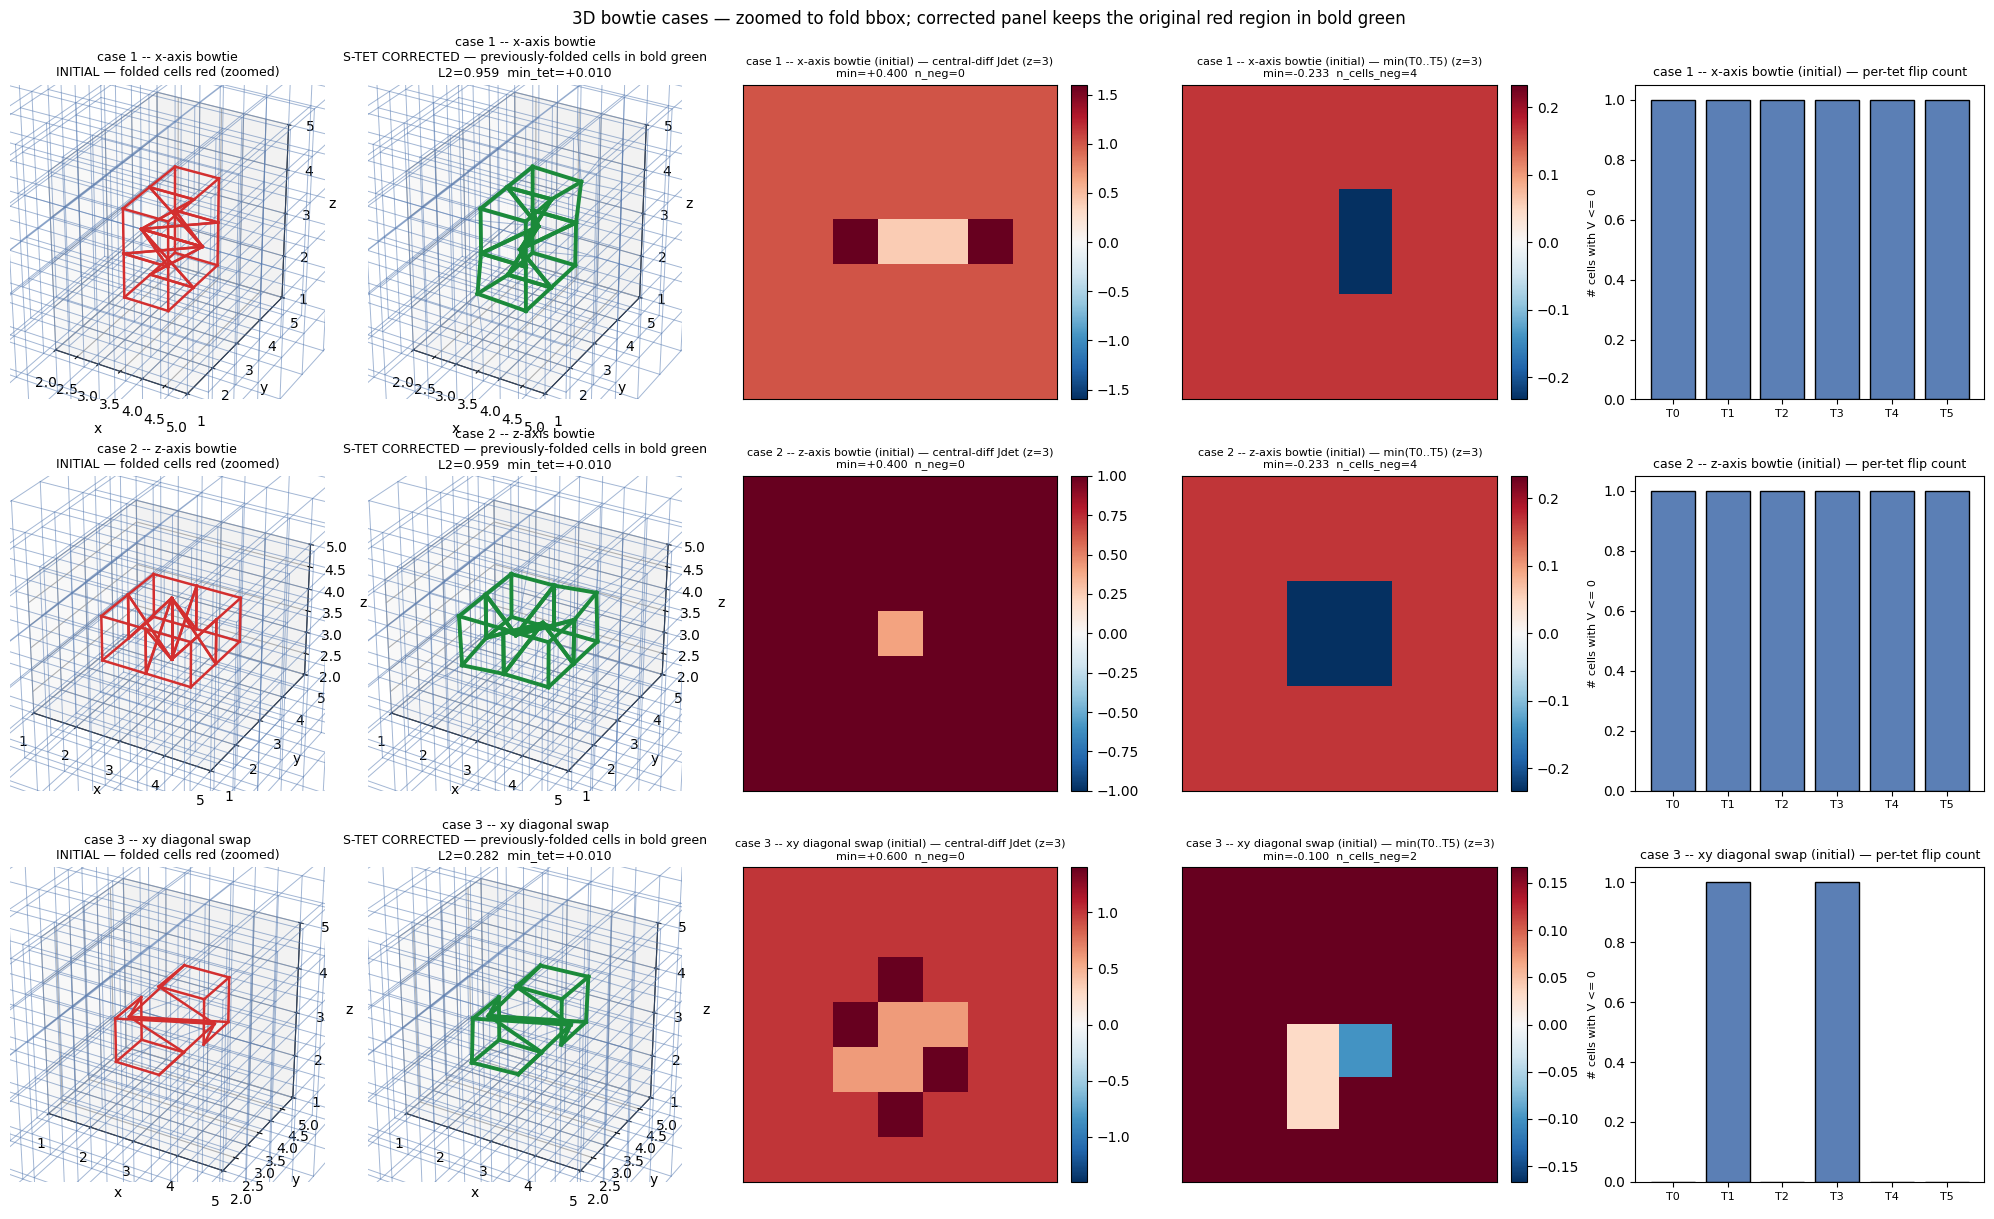

In [21]:
n_cases = len(CASES)
fig = plt.figure(figsize=(20, 4.0 * n_cases), layout='constrained')
gs = fig.add_gridspec(n_cases, 5)

for i, (name, phi) in enumerate(CASES):
    initial_fold_mask = tet_min_per_cell(phi) <= 0

    ax3a = fig.add_subplot(gs[i, 0], projection='3d')
    plot_warped_grid_3d(
        ax3a, phi,
        f'{name}\nINITIAL — folded cells red (zoomed)',
        outline_mask=initial_fold_mask,
        outline_color='#d32f2f',
        outline_lw=1.8,
        zoom_mask=initial_fold_mask,
        zoom_pad=1,
    )

    phi_corr = slsqp_results[name]['tet']['phi']
    r_tet = slsqp_results[name]['tet']
    ax3b = fig.add_subplot(gs[i, 1], projection='3d')
    plot_warped_grid_3d(
        ax3b, phi_corr,
        f'{name}\nS-TET CORRECTED — previously-folded cells in bold green\n'
        f'L2={r_tet["l2"]:.3f}  min_tet={r_tet["min_tet"]:+.3f}',
        outline_mask=initial_fold_mask,
        outline_color='#1b8a3a',
        outline_lw=2.8,
        zoom_mask=initial_fold_mask,
        zoom_pad=1,
    )

    axh1 = fig.add_subplot(gs[i, 2])
    axh2 = fig.add_subplot(gs[i, 3])
    plot_midz_heatmaps([axh1, axh2], phi, name + ' (initial)')

    axb = fig.add_subplot(gs[i, 4])
    plot_per_tet_bars(axb, phi, name + ' (initial)')

plt.suptitle('3D bowtie cases — zoomed to fold bbox; corrected panel keeps the original red region in bold green',
             fontsize=12)
plt.show()

## 2D decomposition — three orthogonal slices through the strongest-displacement plane

3D plots of a 3D fold are still hard to read. Here we slice the field along each axis at the voxel index where the *initial displacement is strongest along that axis* (so the slice actually contains the fold geometry). For each slice we plot the 2D warped quad grid using the same convention as `01_vs-central-diff.ipynb`'s 2D plots.

For each case, six panels: three slice axes × `(initial / corrected)`.

- **Red 2D quad outline** = a 2D cell that is the face of a folded 3D cell (initial panel).
- **Bold green 2D quad outline** = the *same* originally-folded cells, after S-TET (corrected panel).

### Two checks per panel

Every panel title reports **two** independent fold checks, because they don't have to agree:

- `3D min_tet` — minimum of the 6 tet signed volumes over every 3D cell whose face lies in this slice. **This is the truthful 3D fold status.** `OK` means every tet ≥ THRESHOLD, `FOLD` means at least one tet ≤ 0.
- `2D min_tri` — minimum of the 2-triangle TR-BL signed areas over every projected 2D quad in this slice. This is what the picture *looks* like — the 2D bowtie check from notebook `01_vs-central-diff.ipynb` applied to the orthogonal projection of the 3D field.

### Why 3D-OK can co-exist with 2D-X (case 3 is the canonical example)

For the **xy-diagonal swap (case 3)**, S-TET converges to a feasible 3D field (`min_tet = +0.0100 ≥ THRESHOLD`, all 6 tets per cell positive) by adding a small `dz = ±0.047` tilt to the bowtie corners and only slightly retracting the original in-plane `dy` (from `±0.800` down to `±0.680`). That tiny dz lifts the corners out of the `z=3` plane just enough to validate every tet in 3D — but when we project back to xy (drop the z-axis), the lines still cross. The 2D picture still has a bowtie even though the 3D field doesn't.

This is the same diagonal-redistribution behaviour documented in 2D in `09_horizontal-vs-diagonal-bowtie.ipynb`: under L2, SLSQP prefers spreading the correction across more variables (here, into `dz`) rather than retracting the original `dx, dy` because the quadratic cost rewards smaller-but-more-spread changes. Under an L1 objective the corrector would instead concentrate on retracting `dx, dy` and the 2D projection would un-cross — at the price of a larger 3D L2 distance.

In the figure: when a corrected panel says `3D min_tet=+0.010 OK   2D min_tri=-0.594 X2   (3D OK -- 2D crossing is projection of out-of-plane tilt)`, the 3D fold is genuinely fixed; the 2D crossing is an artefact of dropping the slice's normal axis.

For the axis-aligned cases (1 and 2) one of the three projections always reports `(projection orthogonal to displacement)` — the only displacement axis is dropped by that projection, so the warped grid in that slice equals the unwarped grid. Folded 3D cells still appear as red squares on a regular grid; the geometric inversion is in another plane and not visible in this view. Intrinsic to axis-aligned folds, not a missed fix.

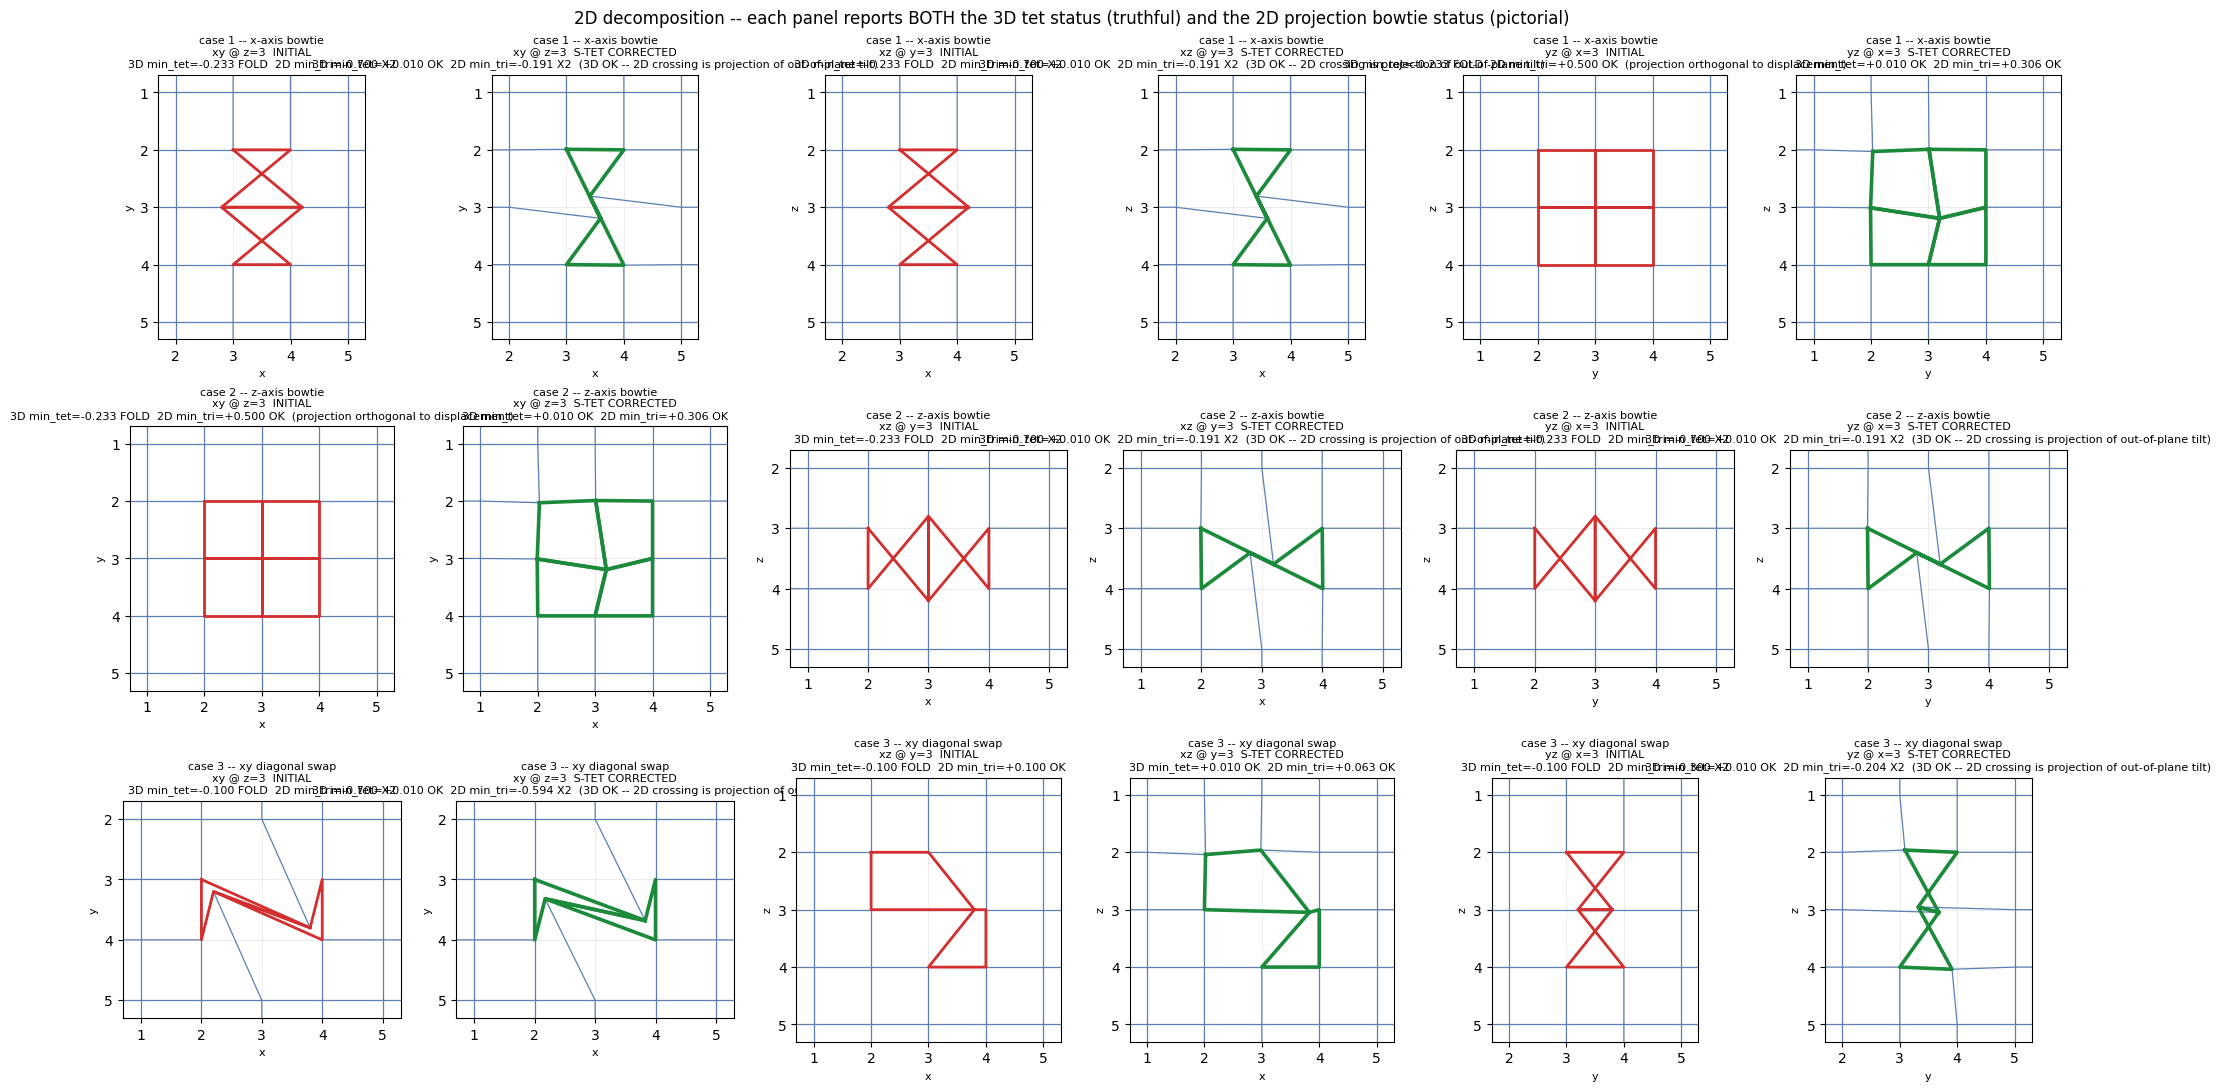

In [22]:
fig, axes = plt.subplots(len(CASES), 6, figsize=(20, 3.6 * len(CASES)),
                          layout='constrained', squeeze=False)
SLICE_AXES = ['xy', 'xz', 'yz']
FIXED_LBL = {'xy': 'z', 'xz': 'y', 'yz': 'x'}


def status_line(phi, axis, idx, threshold=THRESHOLD):
    """Build a one-line status string for the panel title."""
    tri_min, tri_n_neg = slice_2d_tri_min(phi, axis, idx)
    tet_min            = slice_3d_tet_min(phi, axis, idx)
    in_plane           = slice_inplane_disp(phi, axis, idx)
    tet_ok = tet_min >= threshold - 1e-6
    tri_ok = tri_min >  0 - 1e-6
    parts = [f'3D min_tet={tet_min:+.3f} ' + ('OK' if tet_ok else 'FOLD'),
             f'2D min_tri={tri_min:+.3f} ' + ('OK' if tri_ok else 'X' + str(tri_n_neg))]
    note = ''
    if tet_ok and not tri_ok:
        note = '  (3D OK -- 2D crossing is projection of out-of-plane tilt)'
    if in_plane < 1e-9:
        note = '  (projection orthogonal to displacement)'
    return '  '.join(parts) + note


for i, (name, phi) in enumerate(CASES):
    initial_fold_mask = tet_min_per_cell(phi) <= 0
    phi_corr = slsqp_results[name]['tet']['phi']

    for k, axis_name in enumerate(SLICE_AXES):
        si = best_slice_idx(phi, axis_name)
        title_init = (f'{name}\n{axis_name} @ {FIXED_LBL[axis_name]}={si}  INITIAL\n'
                      + status_line(phi, axis_name, si))
        title_corr = (f'{name}\n{axis_name} @ {FIXED_LBL[axis_name]}={si}  S-TET CORRECTED\n'
                      + status_line(phi_corr, axis_name, si))

        plot_warped_slice_2d(
            axes[i, 2 * k], phi, axis_name, si,
            outline_mask_3d=initial_fold_mask,
            outline_color='#d32f2f', outline_lw=2.0,
            title=title_init,
        )
        plot_warped_slice_2d(
            axes[i, 2 * k + 1], phi_corr, axis_name, si,
            outline_mask_3d=initial_fold_mask,
            outline_color='#1b8a3a', outline_lw=2.6,
            title=title_corr,
        )

plt.suptitle('2D decomposition -- each panel reports BOTH the 3D tet status (truthful) and the 2D '
             'projection bowtie status (pictorial)', fontsize=12)
plt.show()

## Summary

**Geometry.** A voxel cell decomposes into 6 tets along the body diagonal `v0=(0,0,0) → v7=(1,1,1)`, one per monotone path through cube edges. Per-tet signed volume is a polynomial in `phi`, smooth, and admissible as an SLSQP constraint. Half the path orderings are even permutations of the cube and half odd — the `TET_SIGN_FLIP` vector is calibrated once at startup against the identity field so that valid cells return `V > 0` for all 6 tets.

**Detection.** On all three test cases the 6-tet check flagged at least one cell where central-difference Jdet did not. The disagreement is the same pathology as in 2D (`01_vs-central-diff.ipynb`): the 2Δ central-difference stencil averages partial derivatives over neighbours so that opposing-sign contributions cancel. The local triangulation can't average — it sees the swap directly.

**Correction.** The S-TET solver consistently produced fields with `min_tet ≥ THRESHOLD` on cases where S-CD terminated thinking the field was clean while at least one tet was still flipped. S-CD typically finishes in `nit=1` (the central-diff Jdet was already ≥ THRESHOLD before optimisation — there was nothing for the CD-constrained solver to do).

**Cost.** On a 7³ grid with 3 channels (1029 variables) the 6-tet constraint vector has length `6 · 6³ = 1296`. SLSQP wall time per case was on the order of seconds — comparable to S-CD. Larger grids will need either the windowed iterative pattern from `dvfopt.core.iterative3d` or a sparse Jacobian for the constraint (analog of `gradients3d.jdet_constraint_jacobian_3d` for tets).

**Next steps (out of scope for this notebook):**
- Promote the helpers in this notebook into `dvfopt/jacobian/tetrahedron_sign.py` mirroring `triangle_sign.py`.
- Add tet-volume constraint mode to `iterative_3d` (currently only central-diff Jdet is supported in 3D, per `CLAUDE.md`).
- Analytic constraint Jacobian for the 6-tet form for SLSQP scaling to larger volumes.
- 24-tet Kuhn split as the analog of `triangle_det2D` (4 triangles per cell).